In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer
import os
from tqdm import tqdm
import joblib

In [2]:
output_folder = "../../bats_transformer/outputs/july_daytime_new_mask_11_5"
dataset_path = "../../bats_transformer/data/july_daytime_chunked_quantile/splits"
raw_audio_folder = "../../audio/audio_07_22/chopped/"

In [3]:
output_folder = "../../bats_transformer/outputs/2022_barn_daytime_2secs_quantile_1_12"
dataset_path = "../../bats_transformer/data/2022_barn_daytime_2secs/splits"
raw_audio_folder = "../../audio/barn_2022"

In [4]:
# Daytime recordings (max 2 seconds) from the barn in 2022, filtered to only include Myca (Myotis californicus) chirps
output_folder = "../../bats_transformer/outputs/2022_barn_2secs_myca_quantile_1_16"
dataset_path = "../../bats_transformer/data/2022_barn_2secs_myca/splits"
raw_audio_folder = "../../audio/barn_2022"

In [5]:
# Nighttime recordings (max 2 seconds) from the lake in Jan-Feb 2022, filtered to only include Myca (Myotis californicus) chirps
output_folder = "../../bats_transformer/outputs/2022_lake_2secs_myca_quantile_1_28"
dataset_path = "../../bats_transformer/data/2022_lake_2secs_myca/splits"
raw_audio_folder = None

In [6]:
scaler_path = f"{dataset_path}/split_scaler.pkl"
filename_to_id_path = f"{dataset_path}/split_filename_to_id.csv"

In [7]:
scaler = joblib.load(open(f'{scaler_path}', 'rb'))
non_scaler_columns = {}

def unscale(df):
    temp_df = df.copy()
    for idx, column in enumerate(temp_df.columns):
        if column not in scaler.feature_names_in_:
            non_scaler_columns[idx] = temp_df[column]
            temp_df.drop(columns=[column], inplace=True)

    all_features = list(scaler.feature_names_in_)
    column_idxs = [] # indices of columns in predictions that are in scaler.feature_names_in_
    for column in scaler.feature_names_in_:
        if column not in temp_df.columns:
            temp_df[column] = 0
        else:
            column_idxs.append(all_features.index(column))

    temp_df = temp_df[scaler.feature_names_in_]

    df_np = temp_df.to_numpy()
    df_np = df_np[:, :-1]

    inverted_predictions = scaler.inverse_transform(temp_df)

    filtered_inverted_predictions = inverted_predictions[:, column_idxs]

    original_df = pd.DataFrame(filtered_inverted_predictions, columns=[temp_df.columns[i] for i in column_idxs])
    return original_df

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
# get all files (not directories) in output_folder
if not os.path.exists(output_folder):
    raise FileNotFoundError(f"output_folder does not exist: {output_folder}")

prediction_files = [
    os.path.join(output_folder, fn)
    for fn in sorted(os.listdir(output_folder))
    if os.path.isfile(os.path.join(output_folder, fn)) and fn.endswith("predictions.log")
]

truth_files = [
    os.path.join(output_folder, fn)
    for fn in sorted(os.listdir(output_folder))
    if os.path.isfile(os.path.join(output_folder, fn)) and fn.endswith("ground_truths.log")
]

print(f"Found {len(prediction_files)} files in {output_folder}")

Found 10 files in ../../bats_transformer/outputs/2022_lake_2secs_myca_quantile_1_28


In [9]:
absolute_errors = []
euclidean_distances = []
for pred_file, truth_file in zip(prediction_files, truth_files):
    pred_df = pd.read_csv(pred_file)
    truth_df = pd.read_csv(truth_file)

    # select numeric columns and keep only common columns
    pred_num = pred_df.select_dtypes(include=[np.number])
    truth_num = truth_df.select_dtypes(include=[np.number])
    common_cols = pred_num.columns.intersection(truth_num.columns)

    if len(common_cols) == 0:
        # nothing numeric in common, append empty dataframe
        absolute_errors.append(pd.DataFrame())
    else:
        # align row counts (use the shorter one) and reset index for safe subtraction
        n = min(len(pred_num), len(truth_num))
        pred_slice = pred_num.loc[: n - 1, common_cols].reset_index(drop=True)
        truth_slice = truth_num.loc[: n - 1, common_cols].reset_index(drop=True)

        # error = truth - prediction, keep absolute per-cell errors
        errors = truth_slice - pred_slice
        abs_errors = errors.abs()

        euclidean_distances.append((errors * errors).sum(axis=1).pow(0.5))

        absolute_errors.append(abs_errors)

In [10]:
euclidean_distances = np.array(euclidean_distances)

In [11]:
euclidean_distances

array([[3.73552736, 4.31629095, 4.63512733, ..., 4.11292782, 5.34821744,
        4.04370965],
       [3.80912017, 4.2580491 , 4.753584  , ..., 4.04174457, 5.42951316,
        4.19581079],
       [3.82237779, 4.20720373, 4.59551613, ..., 3.77754862, 5.38652241,
        4.01801334],
       ...,
       [3.87234478, 4.35571017, 4.53626817, ..., 3.76977369, 5.08056122,
        3.78271053],
       [3.9248099 , 4.29871104, 4.60451607, ..., 3.67913931, 5.03956803,
        3.93927079],
       [3.54890939, 4.32070955, 4.8606656 , ..., 4.23119554, 5.72222881,
        4.18165135]])

In [12]:
for error_df in absolute_errors:
    error_df.drop(["Unnamed: 0", "TimeIndex", "file_id", "chirp_idx"], axis=1, inplace=True, errors="ignore")

In [13]:
absolute_errors[0]

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Bndw32dB,Amp1stQrtl,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start
0,0.329427,0.386903,0.819937,0.641738,0.252028,0.231308,0.875421,0.466904,0.850595,0.452530,...,0.082289,0.792653,0.721121,0.447274,1.533633,0.277308,0.438310,0.255338,0.344162,0.095640
1,0.391561,0.117226,0.093193,0.160821,0.784922,0.675091,0.048673,0.673027,0.169606,0.217930,...,0.412404,0.871220,1.914190,0.119530,1.605967,0.462050,0.509055,0.590364,0.623906,0.697617
2,0.820451,0.452578,0.924398,0.915922,0.605365,0.935910,1.405200,0.870369,0.873590,1.551453,...,0.953786,1.407488,0.827565,1.101862,0.695774,0.525673,0.420158,0.279809,0.284986,0.433851
3,0.005586,1.150178,1.237923,0.967827,0.927663,0.289830,0.550968,0.711657,1.262374,0.067476,...,0.238534,0.908946,0.719090,0.031588,0.486860,0.968158,0.575884,1.181613,0.834976,0.152531
4,0.100266,0.253363,0.562161,0.172282,0.333766,0.017002,0.533696,1.288048,0.653326,0.171740,...,0.044003,0.766897,0.114726,0.143308,0.013555,0.191818,0.412267,0.128423,0.415514,1.160700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,0.210114,0.130419,0.561178,0.870507,1.114501,1.054153,1.097412,0.845129,0.566907,0.648293,...,0.659282,1.400857,2.436087,0.966678,0.371203,0.047210,0.249958,0.019334,0.110635,1.278695
554,0.188037,0.703186,1.918140,1.582628,1.112797,2.699938,1.614690,1.052311,1.864587,1.964245,...,0.592564,3.156431,1.071203,1.084513,0.236777,0.873484,0.554228,0.717796,0.403459,1.114101
555,0.215993,0.059458,1.048342,0.790915,0.071562,0.595231,0.744403,0.364579,1.017269,0.939207,...,0.414907,0.802507,0.316985,1.781739,1.409242,1.031257,0.738090,0.859173,0.549139,0.123783
556,0.187149,0.787882,0.559591,0.745884,0.267242,0.500608,0.493021,0.632343,0.520423,0.713016,...,0.397848,0.090152,0.282917,1.245317,0.216956,0.651333,1.166522,1.177691,1.500726,1.124217


In [14]:
average_error_per_point = []
for error_df in absolute_errors:
    if not error_df.empty:
        avg_error = error_df.mean(axis=1)
        average_error_per_point.append(avg_error.values)
    else:
        average_error_per_point.append(np.nan)  # or some other placeholder for empty dataframes
average_error_per_point = np.array(average_error_per_point)
average_error_per_point

array([[0.55438574, 0.60793153, 0.6807641 , ..., 0.61234677, 0.82659582,
        0.62354682],
       [0.56458457, 0.59854567, 0.70624333, ..., 0.60179691, 0.83877396,
        0.64952357],
       [0.58010668, 0.58585845, 0.68998443, ..., 0.55029625, 0.83203172,
        0.61116151],
       ...,
       [0.57803454, 0.62727289, 0.67788079, ..., 0.54787386, 0.78083213,
        0.57335916],
       [0.58187758, 0.6162496 , 0.6786776 , ..., 0.52409208, 0.7717827 ,
        0.59636148],
       [0.52918386, 0.59587269, 0.72123467, ..., 0.62553819, 0.8892521 ,
        0.64692092]])

In [15]:
def _read_log_to_df(path):
    try:
        # let pandas try to infer delimiter
        return pd.read_csv(path, sep=None, engine="python")
    except Exception:
        try:
            # fallback to generic table reader
            return pd.read_table(path, engine="python")
        except Exception:
            # final fallback: one line per row
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                lines = [ln.rstrip("\n") for ln in f]
            return pd.DataFrame({"line": lines})

# read all .log files into a list of DataFrames
df_list = [_read_log_to_df(p) for p in prediction_files]
truth_list = [_read_log_to_df(p) for p in truth_files]

In [16]:
def cluster_predictions(predictions, index):
    preds_i = np.array([pred.iloc[index] for pred in predictions])
    return preds_i

pred_cluster_0 = cluster_predictions(df_list, 0)
pred_cluster_0[:, 2:len(pred_cluster_0[0]) - 3]

array([[1.8674666, -0.25409847, 0.5459581, 0.3535999, 1.1962336,
        -0.53377664, 0.46786025, 0.39040932, 0.48697498, 0.21260726,
        0.89485985, 0.90819675, 1.2248294, -5.1794276, 0.43822634,
        0.5145039, 0.93055046, 0.6829768, 0.90370935, 0.86045504,
        0.9298075, 1.0742407, 0.54068, 0.16531447, 0.20492871,
        -0.09175093, -0.52820545, 0.542306, 0.64243704, 0.79442245,
        0.88983804, -0.3446244],
       [1.8239396, 0.05991485, 0.57462126, 0.4238106, 1.2561939,
        -0.54093474, 0.34516945, 0.55312896, 0.4693331, 0.19773936,
        0.92413926, 0.96444345, 1.2592833, -5.1382484, 0.26943588,
        0.47913206, 0.8995752, 0.65354, 0.8979753, 0.81948984,
        0.95225024, 1.0643163, 0.5460558, 0.16554436, 0.38380423,
        0.10020251, -0.69917, 0.58667517, 0.7047076, 0.7818396,
        0.91385704, -0.36202675],
       [1.9388313, -0.05743788, 0.5597389, 0.4973904, 1.1175928,
        -0.58955973, 0.42461404, 0.5927002, 0.577684, 0.26934388,
        0.8

In [19]:
from scipy import special
from scipy.spatial.distance import pdist

def compute_cluster_measures(X, radius_for_density=None):
    """
    Compute cluster measures for an array X of shape (n_points, n_features).
    Returns a dict with:
      - n, dim
      - centroid
      - distances (to centroid)
      - radius (max distance to centroid)
      - avg_radius (mean distance to centroid)
      - std_radius
      - diameter (max pairwise distance)
      - avg_pairwise_distance
      - tightness = 1 / (1 + avg_pairwise_distance)  (higher -> tighter)
      - density = n_points / vol_ball(radius)  (uses 'radius' or radius_for_density if provided)
    """
    X = X[:, 2:len(pred_cluster_0[0]) - 3]
    X = np.asarray(X, dtype=float)
    
    if X.ndim != 2:
        raise ValueError("X must be 2D (n_points, n_features)")
    n, d = X.shape

    centroid = X.mean(axis=0)
    distances = np.linalg.norm(X - centroid, axis=1)
    radius = float(distances.max()) if n > 0 else 0.0
    avg_radius = float(distances.mean()) if n > 0 else 0.0
    std_radius = float(distances.std(ddof=0)) if n > 0 else 0.0

    if n > 1:
        pairwise = pdist(X, metric="euclidean")
        diameter = float(pairwise.max())
        avg_pairwise = float(pairwise.mean())
    else:
        pairwise = np.array([])
        diameter = 0.0
        avg_pairwise = 0.0

    # tightness: inverse of typical pairwise distance (bounded)
    tightness = 1.0 / (1.0 + avg_pairwise) if avg_pairwise >= 0 else np.nan

    # density: n / volume_of_d_ball(radius)
    r = radius_for_density if (radius_for_density is not None) else radius
    if r <= 0:
        density = np.inf if n > 0 else 0.0
    else:
        # Volume of d-dimensional ball: V_d(r) = pi^(d/2) / Gamma(d/2 + 1) * r^d
        vol_unit_ball = (np.pi ** (d / 2.0)) / special.gamma(d / 2.0 + 1.0)
        vol = vol_unit_ball * (r ** d)
        density = n / vol if vol > 0 else np.inf

    return {
        "n_points": n,
        "dim": d,
        "centroid": centroid,
        "distances_to_centroid": distances,
        "radius_max": radius,
        "radius_mean": avg_radius,
        "radius_std": std_radius,
        "diameter_pairwise": diameter,
        "avg_pairwise_distance": avg_pairwise,
        "tightness": tightness,
        "volume": vol,
        "density": density,
    }

measures_pred_cluster = compute_cluster_measures(cluster_predictions(df_list, 0))
for k, v in measures_pred_cluster.items():
    if k == "centroid":
        print(f"{k}: array(shape={v.shape})")
    elif k == "distances_to_centroid":
        print(f"{k}: {v}")
    else:
        print(f"{k}: {v}")

n_points: 10
dim: 32
centroid: array(shape=(32,))
distances_to_centroid: [0.32472668 0.34897254 0.33228683 0.49389339 0.3767048  0.36549062
 0.60918827 0.25494043 0.36066167 0.48945191]
radius_max: 0.6091882719101073
radius_mean: 0.3956317138119913
radius_std: 0.09877490679196654
diameter_pairwise: 1.0334627374450818
avg_pairwise_distance: 0.5924091221468947
tightness: 0.6279793214521369
volume: 5.569644143009104e-13
density: 17954468442210.59


In [20]:
error_cluster = cluster_predictions(absolute_errors, 0)

In [21]:
tightness = []
radii = []
densities = []
error_densities = []
for i in range(len(df_list[0])):
    pred_cluster_i = cluster_predictions(df_list, i)
    measures = compute_cluster_measures(pred_cluster_i)
    tightness.append(measures["tightness"])
    radii.append(measures["radius_mean"])
    densities.append(measures["density"])

    error_cluster_i = cluster_predictions(absolute_errors, i)
    error_measures = compute_cluster_measures(error_cluster_i)
    error_densities.append(error_measures["density"])
    # print(measures["tightness"])
# copy file_id and chirp_idx from df_list as ints
df_tightness = df_list[0][['file_id', 'chirp_idx']].copy().astype(int)
# df_tightness.insert(0, 'id', df_list[0].index)
df_tightness['tightness'] = tightness
df_tightness['radius_mean'] = radii
df_tightness['density'] = densities
df_tightness['average_error_per_point'] = average_error_per_point.mean(axis=0)
df_tightness['error_density'] = error_densities
df_tightness['euclidean_distance'] = euclidean_distances.mean(axis=0)
df_tightness

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance
0,1039,10,0.627979,0.395632,1.795447e+13,0.572383,1.463103e+15,3.830414
1,1039,9,0.643326,0.369565,1.741661e+14,0.603087,2.562899e+15,4.255110
2,1039,8,0.624624,0.405090,3.443769e+12,0.687735,6.128022e+13,4.635760
3,1039,7,0.637144,0.382486,2.627954e+15,0.749664,1.876812e+15,4.953883
4,1039,6,0.632494,0.389968,3.496682e+14,0.650974,4.553825e+13,7.764713
...,...,...,...,...,...,...,...,...
553,1090,10,0.637700,0.383417,4.910904e+13,0.596325,1.576547e+13,4.464012
554,1090,9,0.645946,0.372097,2.870314e+15,0.933184,1.777334e+15,6.799188
555,1090,8,0.640552,0.379333,9.949279e+13,0.578274,1.699297e+13,3.948870
556,1090,7,0.665639,0.329097,2.713251e+14,0.830721,7.394526e+14,5.383677


In [22]:
# get the range of file_ids
min_file_id = df_tightness['file_id'].min()
max_file_id = df_tightness['file_id'].max()

0.2515155273789966 0.32146769048789464 0.3513683133860459 0.38993191340801137 0.7807399384107457


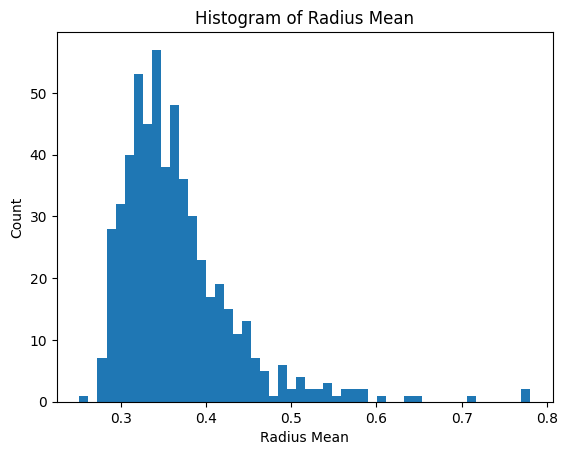

In [23]:
plt.hist(df_tightness['radius_mean'], bins=50)
print(np.percentile(df_tightness['radius_mean'], 0), np.percentile(df_tightness['radius_mean'], 25), np.percentile(df_tightness['radius_mean'], 50), np.percentile(df_tightness['radius_mean'], 75), np.percentile(df_tightness['radius_mean'], 100))
plt.title('Histogram of Radius Mean')
plt.xlabel('Radius Mean')
plt.ylabel('Count');

In [24]:
low_confidence_threshold = np.percentile(df_tightness['radius_mean'], 90)
low_confidence_threshold

0.4437660540175321

In [25]:
# get the indices of the low confidence samples
low_confidence_indices = df_tightness.index[df_tightness['radius_mean'] >= low_confidence_threshold].tolist()

In [26]:
df_tightness["low_confidence"] = df_tightness['radius_mean'] >= low_confidence_threshold
df_tightness

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence
0,1039,10,0.627979,0.395632,1.795447e+13,0.572383,1.463103e+15,3.830414,False
1,1039,9,0.643326,0.369565,1.741661e+14,0.603087,2.562899e+15,4.255110,False
2,1039,8,0.624624,0.405090,3.443769e+12,0.687735,6.128022e+13,4.635760,False
3,1039,7,0.637144,0.382486,2.627954e+15,0.749664,1.876812e+15,4.953883,False
4,1039,6,0.632494,0.389968,3.496682e+14,0.650974,4.553825e+13,7.764713,False
...,...,...,...,...,...,...,...,...,...
553,1090,10,0.637700,0.383417,4.910904e+13,0.596325,1.576547e+13,4.464012,False
554,1090,9,0.645946,0.372097,2.870314e+15,0.933184,1.777334e+15,6.799188,False
555,1090,8,0.640552,0.379333,9.949279e+13,0.578274,1.699297e+13,3.948870,False
556,1090,7,0.665639,0.329097,2.713251e+14,0.830721,7.394526e+14,5.383677,False


In [27]:
df_list[0]

,Unnamed: 0,TimeIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,model_id
0,0,11.0,1.867467,-0.254098,0.545958,0.353600,1.196234,-0.533777,0.467860,0.390409,...,-0.091751,-0.528205,0.542306,0.642437,0.794422,0.889838,-0.344624,1039.0,10.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
1,1,10.0,1.399564,-0.033895,0.406828,0.251423,1.082528,-0.504552,0.306814,0.327954,...,-0.026056,-0.760884,0.318134,0.440266,0.566555,0.658383,-0.303391,1039.0,9.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
2,2,9.0,0.697094,0.357086,0.734426,0.526019,1.123185,-0.480468,0.451321,0.388537,...,-0.261381,-1.155648,0.453502,0.534124,0.689711,0.806605,-0.335939,1039.0,8.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
3,3,8.0,0.598029,0.073110,0.414593,0.222961,0.914304,-0.471818,0.197816,0.299827,...,-0.248260,-1.190967,0.096456,0.300644,0.301040,0.485191,-0.386053,1039.0,7.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
4,4,7.0,0.546154,0.100124,0.241249,0.135160,0.960827,-0.539707,0.210913,0.212690,...,-0.280631,-0.940611,0.079943,0.116124,0.278997,0.304223,-0.284247,1039.0,6.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,553,11.0,0.198822,0.337642,-0.513305,-0.439814,0.005364,-0.234687,-0.421182,-0.055006,...,-0.034854,0.043650,-0.391438,-0.420772,-0.398369,-0.343506,-0.202101,1090.0,10.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
554,554,10.0,0.058367,0.090415,-0.377969,-0.410577,-0.230232,-0.051271,-0.315661,-0.058468,...,0.307506,0.155885,-0.349295,-0.338531,-0.308748,-0.348755,-0.142164,1090.0,9.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
555,555,9.0,-0.054492,0.084054,-0.256679,-0.284483,-0.177325,0.046077,-0.155030,-0.109552,...,0.147061,-0.035210,-0.235654,-0.261231,-0.202720,-0.278329,-0.203241,1090.0,8.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
556,556,8.0,-0.218929,-0.232420,0.037179,0.002238,0.000617,0.156168,0.132913,-0.080825,...,-0.026913,-0.211387,0.005667,0.059932,0.126724,0.159970,-0.096385,1090.0,7.0,models/2022_lake_2secs_myca_quantile_1_28/mode...


In [28]:
truth_list[0]

,Unnamed: 0,TimeIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,model_id
0,0,11.0,2.196894,-0.641002,1.365895,0.995338,1.448261,-0.302469,1.343281,-0.076494,...,-0.539025,-2.061839,0.819614,1.080747,1.049761,1.234000,-0.440265,1039.0,10.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
1,1,10.0,1.791125,-0.151121,0.500021,0.090602,1.867450,-1.179643,0.355486,1.000981,...,-0.145587,0.845083,0.780184,0.949322,1.156919,1.282289,-1.001008,1039.0,9.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
2,2,9.0,1.517545,-0.095492,-0.189971,-0.389902,1.728550,-1.416378,-0.953879,1.258907,...,0.840481,-0.459874,-0.072171,0.113966,0.409902,0.521619,-0.769790,1039.0,8.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
3,3,8.0,0.592444,1.223287,1.652515,1.190787,1.841967,-0.761648,0.748784,1.011484,...,-0.216672,-0.704107,1.064614,0.876528,1.482653,1.320167,-0.538585,1039.0,7.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
4,4,7.0,0.445887,0.353487,0.803410,0.307441,1.294593,-0.556709,-0.322784,1.500738,...,-0.137323,-0.927056,-0.111875,0.528391,0.150574,0.719736,-1.444948,1039.0,6.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,553,11.0,-0.011291,0.207223,0.047872,0.430694,-1.109137,0.819466,0.676231,-0.900135,...,-1.001532,0.414854,-0.344228,-0.170814,-0.379035,-0.232871,1.076593,1090.0,10.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
554,554,10.0,-0.129670,0.793602,-2.296108,-1.993205,0.882566,-2.751209,-1.930351,0.993843,...,-0.777007,-0.080892,-1.222779,-0.892759,-1.026545,-0.752214,-1.256265,1090.0,9.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
555,555,9.0,-0.270485,0.143512,-1.305021,-1.075398,-0.105764,-0.549154,-0.899433,0.255027,...,1.928799,1.374032,-1.266912,-0.999321,-1.061893,-0.827468,-0.079458,1090.0,8.0,models/2022_lake_2secs_myca_quantile_1_28/mode...
556,556,8.0,-0.406079,0.555462,-0.522412,-0.743646,-0.266625,-0.344440,-0.360108,-0.713168,...,1.218404,0.005569,-0.645666,-1.106590,-1.050967,-1.340756,-1.220602,1090.0,7.0,models/2022_lake_2secs_myca_quantile_1_28/mode...


In [29]:
unscaled_df_0 = unscale(df_list[0])
unscaled_df_0

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Bndw32dB,Amp1stQrtl,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start
0,1908.172495,75.000000,86.523822,36.820405,60.131224,61.070556,63.798516,41.306045,86.058790,65.468853,...,57.277759,84.317556,13212.197026,14978.360820,11555.097094,25.002704,23.531860,214.020697,220.245663,6.631703
1,1760.790296,79.000000,85.071648,35.628784,59.616260,61.581383,62.880144,40.313028,84.286651,64.759674,...,49.419470,79.238155,12083.895538,15241.344340,10593.818889,22.727718,21.319901,194.129272,197.209429,6.910631
2,1364.622528,85.000000,88.557726,38.898383,59.783542,62.055066,63.700028,41.282692,88.123983,66.453125,...,39.890084,69.583431,11183.741643,14225.688205,8896.125910,24.218656,22.303497,204.282669,212.747245,6.682397
3,1294.729437,81.000000,85.139113,35.324068,58.893463,62.266792,62.347614,39.888617,84.780611,66.039330,...,37.901399,73.723925,11719.475639,14307.501800,8749.403513,20.350725,19.821830,174.242351,182.153376,6.342173
4,1255.624602,81.000000,83.325972,34.075687,59.077235,60.986732,62.413585,38.662514,82.269113,65.452705,...,38.406984,79.880424,11757.555443,14138.248156,9851.084899,20.166147,17.670069,172.744224,167.342718,7.049031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,992.822377,85.000000,72.712854,26.638842,55.118689,66.775654,59.413277,34.703072,72.472414,60.746408,...,38.441133,86.866779,13347.831359,15203.474132,14159.280809,14.843261,10.735848,129.674418,119.309767,7.706494
554,892.496806,81.000000,74.129065,26.945307,54.335469,70.243696,59.893604,34.659474,73.582546,61.383225,...,44.078275,80.310498,12656.506095,16735.591447,14706.865231,15.300082,11.740652,134.642727,118.771822,8.212530
555,809.793181,81.000000,76.118873,28.543040,54.521387,72.032830,60.666882,34.010921,75.474227,62.198997,...,42.759212,75.591347,12486.118630,15998.044167,13786.732622,16.516310,12.808260,140.933416,123.440036,7.694041
556,698.878355,75.697895,80.926408,32.310821,55.102906,73.828874,62.064720,34.386713,80.639704,63.982559,...,41.666667,73.597465,12353.524042,15238.332858,12954.108028,19.325952,17.091501,161.750087,156.080633,8.672230


In [30]:
unscaled_truth_list_0 = unscale(truth_list[0])
# add file_id and chirp_idx back to unscaled_truth_list_0
unscaled_truth_list_0['file_id'] = truth_list[0]['file_id'].astype(int)
unscaled_truth_list_0['chirp_idx'] = truth_list[0]['chirp_idx'].astype(int)
unscaled_truth_list_0

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
0,1952.000011,66.0,96.158684,44.598516,61.437991,65.504656,70.148691,34.431935,96.158684,70.148691,...,16527.130672,13056.246133,5778.950009,27.786076,27.970411,242.288106,260.169814,5.991460,1039,10
1,1886.000008,77.0,86.049614,33.516771,64.294329,47.009236,63.138954,52.091316,86.049614,63.138954,...,21522.557313,14748.268862,18103.736119,27.475878,26.572488,256.128678,268.629707,3.079585,1039,9
2,1810.000040,78.0,77.448164,27.228307,63.293010,42.370659,57.023440,57.906567,77.448164,57.023440,...,14751.228358,19402.585602,11857.859443,18.352053,17.652188,181.987201,185.056130,4.191730,1039,8
3,1291.000009,115.0,98.870084,47.086235,64.084846,56.225458,65.463989,52.347840,98.870084,65.463989,...,8978.939218,14443.475086,10812.267166,30.280464,25.923295,307.438836,273.939478,5.356962,1039,7
4,1175.999992,85.0,89.439404,36.285696,60.602086,60.615042,59.861959,63.501472,89.439404,66.890811,...,12232.084651,14788.244810,9915.377682,17.945954,22.234256,163.756514,203.706458,1.157496,1039,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,65.033890,...,4887.441377,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090,10
554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,52.235091,...,17695.370816,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090,9
555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,57.253009,...,13915.889054,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090,8
556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,59.687491,...,13638.972049,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090,7


In [31]:
# plt.hist(unscaled_truth_list_0["UpprKnToKnAmp"], bins=100);

In [32]:
sample_file_id = max_file_id

In [33]:
truth_sample = unscaled_truth_list_0[df_list[0]['file_id'] == sample_file_id]
truth_sample = truth_sample.sort_values("TimeInFile")
truth_sample = truth_sample.drop_duplicates(subset=["TimeInFile"])
truth_sample

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
557,498.000006,83.0,74.201596,27.947020,53.791106,81.381640,61.292379,28.541578,74.201596,61.292379,...,13759.016036,15369.187689,7432.857161,15.496670,12.514597,157.566918,142.556677,20.007363,1090,6
556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,59.687491,...,13638.972049,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090,7
555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,57.253009,...,13915.889054,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090,8
554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,52.235091,...,17695.370816,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090,9
553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,65.033890,...,4887.441377,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090,10
552,1017.000004,85.0,80.653303,36.778477,53.310491,81.720040,63.754151,34.487356,80.653303,63.754151,...,8728.682706,10901.766281,18207.532192,23.670113,14.641882,180.829959,134.399798,11.069360,1090,11
551,1086.000003,68.0,84.449737,35.719804,56.510515,79.347355,69.412602,32.140701,84.449737,69.412601,...,11888.192904,7729.724521,12876.691362,22.309180,16.923335,196.512805,164.478263,4.574967,1090,12
550,1193.999989,55.0,93.910912,40.428733,60.601896,57.547980,66.032109,35.487921,93.910912,66.032109,...,9338.777313,16271.002448,16370.667528,32.832315,29.754573,282.566649,268.915812,1.993205,1090,13


In [34]:
preds_sample = unscaled_df_0[df_list[0]['file_id'] == sample_file_id]
preds_sample = preds_sample.sort_values("TimeInFile")
preds_sample

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Bndw32dB,Amp1stQrtl,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start
557,600.490599,69.000000,84.792936,36.031583,55.908506,72.436958,63.757521,35.570189,84.719604,66.253045,...,41.666667,72.528898,12095.886297,15375.305431,13383.455593,22.872564,20.319658,185.364491,185.162806,6.926750
556,698.878355,75.697895,80.926408,32.310821,55.102906,73.828874,62.064720,34.386713,80.639704,63.982559,...,41.666667,73.597465,12353.524042,15238.332858,12954.108028,19.325952,17.091501,161.750087,156.080633,8.672230
555,809.793181,81.000000,76.118873,28.543040,54.521387,72.032830,60.666882,34.010921,75.474227,62.198997,...,42.759212,75.591347,12486.118630,15998.044167,13786.732622,16.516310,12.808260,140.933416,123.440036,7.694041
554,892.496806,81.000000,74.129065,26.945307,54.335469,70.243696,59.893604,34.659474,73.582546,61.383225,...,44.078275,80.310498,12656.506095,16735.591447,14706.865231,15.300082,11.740652,134.642727,118.771822,8.212530
553,992.822377,85.000000,72.712854,26.638842,55.118689,66.775654,59.413277,34.703072,72.472414,60.746408,...,38.441133,86.866779,13347.831359,15203.474132,14159.280809,14.843261,10.735848,129.674418,119.309767,7.706494
552,1073.212396,84.000000,72.589589,26.786945,53.716416,70.486625,59.387478,33.298726,72.480945,60.820166,...,40.723328,78.329063,11556.308898,14916.689167,14386.439867,13.930129,10.009831,123.946039,109.875664,9.696539
551,1177.035991,84.000000,75.778705,30.393149,54.402179,72.540872,60.547703,34.221994,75.972428,61.931342,...,47.251942,70.896492,11452.383589,14601.726574,14964.389632,16.815691,12.801578,141.335873,123.499247,9.411445
550,1265.858002,76.967392,81.336417,33.511576,55.346159,72.512464,62.093584,36.637561,81.522987,64.009523,...,42.777383,71.804150,11790.352552,14146.549136,14135.687012,20.233302,17.016135,165.542177,149.100385,8.330775


In [35]:
df_tightness[df_tightness['file_id'] == sample_file_id]

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence
550,1090,13,0.679023,0.315343,1.320576e+17,0.794153,9.460816e+16,5.190038,False
551,1090,12,0.656899,0.351850,7.034267e+16,0.707563,7.055864e+15,4.806625,False
552,1090,11,0.654011,0.352008,1.521386e+14,0.666101,2.100679e+13,4.705857,False
553,1090,10,0.637700,0.383417,4.910904e+13,0.596325,1.576547e+13,4.464012,False
554,1090,9,0.645946,0.372097,2.870314e+15,0.933184,1.777334e+15,6.799188,False
555,1090,8,0.640552,0.379333,9.949279e+13,0.578274,1.699297e+13,3.948870,False
556,1090,7,0.665639,0.329097,2.713251e+14,0.830721,7.394526e+14,5.383677,False
557,1090,6,0.655711,0.354431,3.925926e+17,0.618947,5.332848e+16,4.044127,False


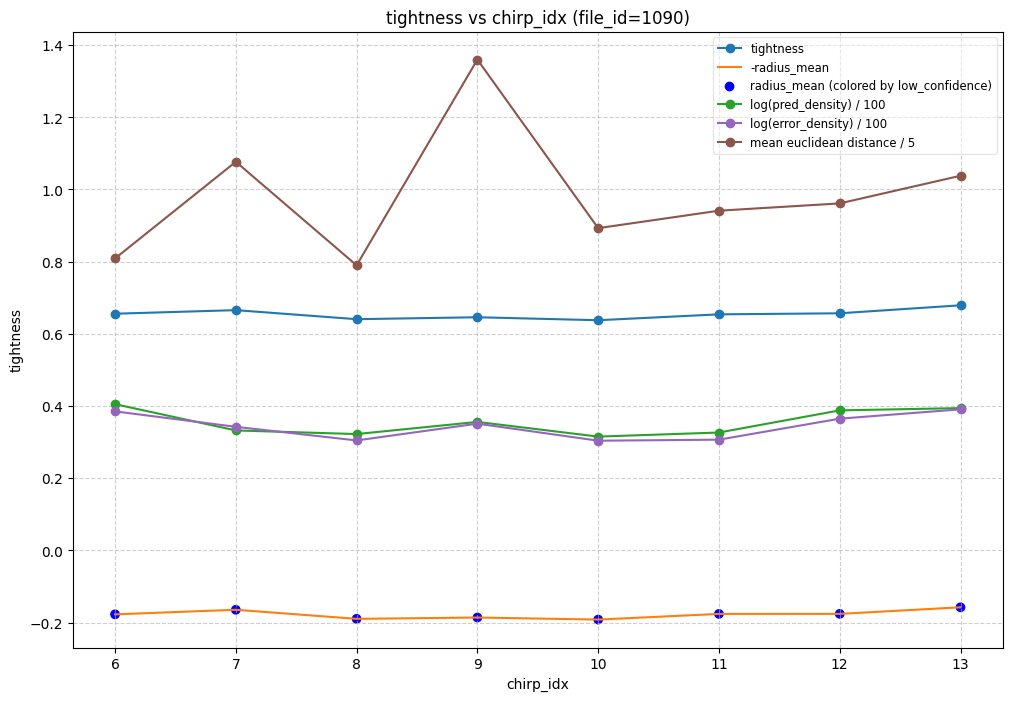

<Axes: title={'center': 'tightness vs chirp_idx (file_id=1090)'}, xlabel='chirp_idx', ylabel='tightness'>

In [36]:
import math
def plot_tightness_by_file(file_id, df=df_tightness, ax=None, figsize=(12, 8), show=True, save_filename=None):
    """
    Plot tightness vs chirp_idx for a given file_id using the existing `df_tightness`.
    Returns the matplotlib Axes instance.
    """
    sel = df[df["file_id"] == file_id].copy()
    if sel.empty:
        raise ValueError(f"No rows found for file_id={file_id}")

    sel = sel.sort_values("chirp_idx")
    x = sel["chirp_idx"]
    # if chirp_idx are whole numbers, cast to int for nicer x ticks
    if np.allclose(x % 1, 0):
        x = x.astype(int)
    # y = sel["tightness"]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    ax.plot(x, sel["tightness"], marker="o", linestyle="-", color="C0")
    # Color points based on the value of sel["low_confidence"]
    colors = sel["low_confidence"].map({True: "red", False: "blue"})
    ax.plot(x, sel["radius_mean"] / -2, marker="", linestyle="-", color="C1")
    ax.scatter(x, sel["radius_mean"] / -2, c=colors, marker="o", label="radius_mean (colored by low_confidence)")
    ax.plot(x, np.log(sel["density"]) / 100, marker="o", linestyle="-", color="C2")
    # ax.plot(x, sel["average_error_per_point"], marker="o", linestyle="-", color="C3")
    ax.plot(x, np.log(sel["error_density"]) / 100, marker="o", linestyle="-", color="C4")
    ax.plot(x, sel["euclidean_distance"] / 5, marker="o", linestyle="-", color="C5")
    ax.set_xlabel("chirp_idx")
    ax.set_ylabel("tightness")

    # ensure x-axis ticks are integer indices (avoid fractional chirp_idx labels)
    x_min = int(np.floor(x.min()))
    x_max = int(np.ceil(x.max()))
    if x_max < x_min:
        x_min, x_max = x_max, x_min
    # limit number of ticks to avoid overcrowding
    if x_max - x_min <= 20:
        ticks = np.arange(x_min, x_max + 1)
    else:
        step = max(1, (x_max - x_min) // 20)
        ticks = np.arange(x_min, x_max + 1, step)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])

    ax.set_title(f"tightness vs chirp_idx (file_id={file_id})")
    ax.grid(True, linestyle="--", alpha=0.6)
    # ax.set_ylim(-1,0.1)

    # label the three plotted series (they were plotted above in order) and show legend
    labels = ["tightness", "-radius_mean", "log(pred_density) / 100", "log(error_density) / 100", "mean euclidean distance / 5"]
    for line, lbl in zip(ax.lines[-len(labels):], labels):
        line.set_label(lbl)
    ax.legend(fontsize="small", framealpha=0.5)

    if show:
        plt.show()

    if save_filename:
        fig_filename = f"{save_filename}.png"
        ax.figure.savefig(fig_filename)
        # print(f"Saved figure to {fig_filename}")
        plt.close()
    return ax

# Example:
plot_tightness_by_file(sample_file_id)

In [37]:
# Peak detection courtesy of Andreas

import sys
sys.path.append("..")
from peak_detection.data_series_analyzer import DataSeriesAnalyzer

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ipykernel_launcher.py(13239): 2026-01-31 21:25:07,479;INFO: Found 29 scenes



=== Raw Data ===
Mean:     0.37
Median:   0.35
Std Dev:  0.07
Min:      0.25
Max:      0.78
Frames:   558
Scenes:   29

=== Smoothed Data ===
Mean:     0.37
Median:   0.36
Std Dev:  0.04
Min:      0.31
Max:      0.56
Frames:   558
Scenes:   29


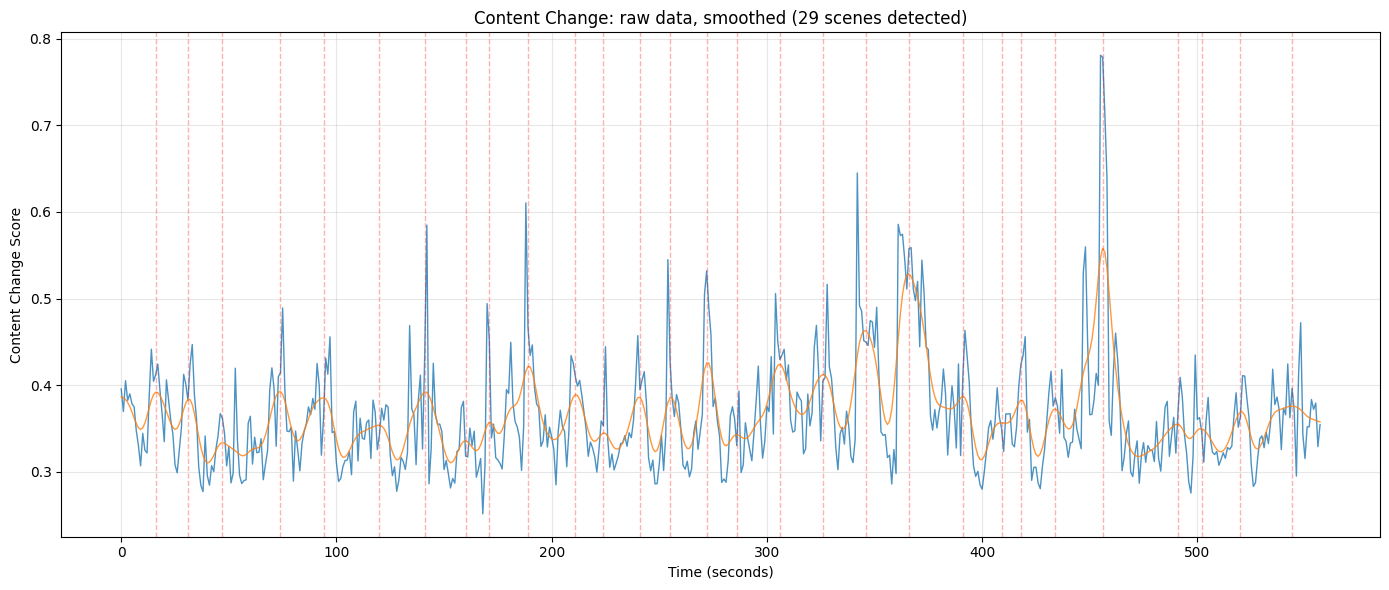

In [38]:
sel = df_tightness[df_tightness["file_id"] == sample_file_id].copy()
data = df_tightness['radius_mean']
data.index = np.arange(len(data))
analyzer = DataSeriesAnalyzer(data)
# Get a df with columns:
# 'frame_number', 'prominence', 'plateau', 'smoothed_content_val', 'content_vals'
peaks_info = analyzer.analyze(sigma=3)

analyzer.print_statistics(data, title="Raw Data")
analyzer.print_statistics(analyzer.get_smoothed_data(), title="Smoothed Data")
# Create visualizations
# log.info("\nGenerating visualizations...")
# Time series with optional interactive preview
fig: plt.Figure = analyzer.plot_timeseries(
        [data, 
            pd.Series(analyzer.get_smoothed_data())
        ],
        labels=['raw data', 'smoothed'],
        interactive=False
)
# log.info("Waiting for user to close charts...")
plt.show(block=False)

In [39]:
def detect_uncertainty_peaks(file_id, df, measure, sigma=3):
    """
    Detect peaks in tightness for a given file_id using DataSeriesAnalyzer.
    Returns a list of chirp_idx where peaks were detected.
    """
    sel = df[df["file_id"] == file_id].copy()
    # sort sel by chirp_idx
    sel = sel.sort_values("chirp_idx")
    data = sel[measure]
    # reverse polarity of values if measure is density (because we want to match peaks with low density moments)
    if measure == "density":
        data = -sel[measure]
    data.index = np.arange(len(data))
    
    analyzer = DataSeriesAnalyzer(data)
    # Get a df with columns:
    # 'frame_number', 'prominence', 'plateau', 'smoothed_content_val', 'content_vals'
    peaks_info = analyzer.analyze(sigma=sigma)
    # print(peaks_info)
    return peaks_info

detect_uncertainty_peaks(sample_file_id, df_tightness, "radius_mean", sigma=0)

ipykernel_launcher.py(13239): 2026-01-31 21:25:07,643;INFO: Found 2 scenes


,frame_number,prominence,plateau,smoothed_content_val,content_vals
2,2,0.007236,1,0.379333,0.379333
4,4,0.054320,1,0.383417,0.383417


100%|██████████| 52/52 [00:00<00:00, 2617.48it/s]


mean_smoothed_density_range: 1.837794e+20
t-test against large value: TtestResult(statistic=1.4999374254986506, pvalue=0.9301019034367165, df=51)


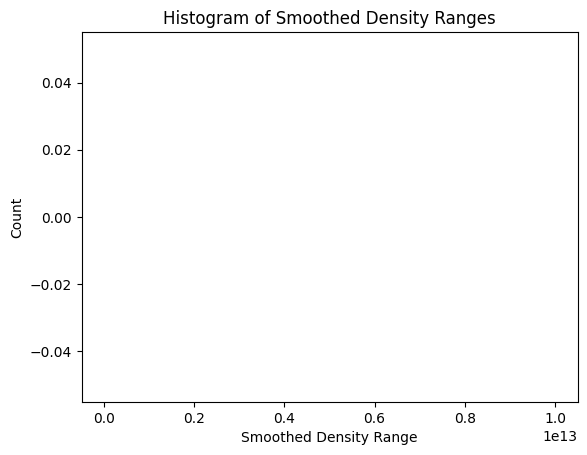

In [40]:
from scipy.stats import ttest_1samp
from scipy.ndimage import gaussian_filter
PREDICTION_OFFSET = 4
SIGMA = 1
MEASURE = "density"

density_ranges = []
density_ranges_smoothed = []
for file_id in tqdm(df_tightness['file_id'].unique()):
    sel = df_tightness[df_tightness['file_id'] == file_id]
    density_range = sel[MEASURE].max() - sel[MEASURE].min()
    density_ranges.append(density_range)
    smoothed = gaussian_filter(sel[MEASURE], sigma=SIGMA, order=0, mode='reflect')
    density_range_smoothed = smoothed.max() - smoothed.min()
    density_ranges_smoothed.append(density_range_smoothed)
# add a column in df_tightness for whether or not a ttest_1samp for each density_range is significantly larger than the sample
for file_id, density_range in zip(df_tightness['file_id'].unique(), density_ranges_smoothed):
    sel = df_tightness[df_tightness['file_id'] == file_id]
    ttest_res = ttest_1samp(density_ranges_smoothed, density_range, alternative='greater')
    df_tightness.loc[sel.index, 'large_range'] = not (ttest_res.pvalue < 0.5)

mean_smoothed_density_range = np.mean(density_ranges_smoothed)
print("mean_smoothed_density_range:", f"{mean_smoothed_density_range:e}")
print("t-test against large value:", ttest_1samp(density_ranges_smoothed, 1.5e15, alternative='less'))
plt.hist(density_ranges_smoothed, range=(0, 1e13))
plt.title("Histogram of Smoothed Density Ranges")
plt.xlabel("Smoothed Density Range")
plt.ylabel("Count");

  0%|          | 0/52 [00:00<?, ?it/s]ipykernel_launcher.py(13239): 2026-01-31 21:25:07,946;INFO: Found 1 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:07,963;INFO: Found 0 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:07,967;INFO: Found 1 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:07,972;INFO: Found 1 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:07,977;INFO: Found 1 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:07,984;INFO: Found 0 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:07,988;INFO: Found 1 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:07,995;INFO: Found 0 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:07,999;INFO: Found 0 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:08,003;INFO: Found 2 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:08,009;INFO: Found 1 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:08,015;INFO: Found 0 scenes
ipykernel_launcher.py(13239): 2026-01-31 21:25:08,018;INFO: Fo

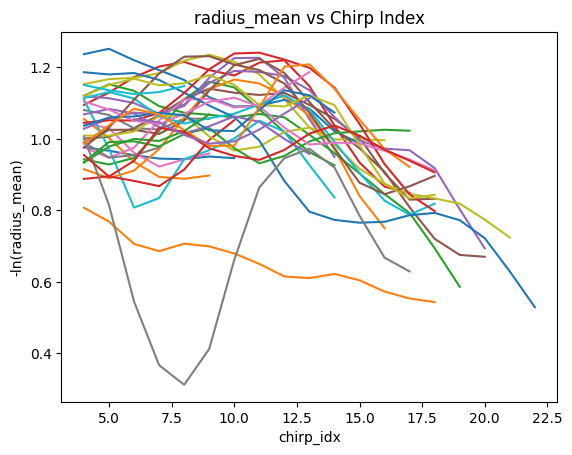

In [41]:
# recall that the measures are:
# tightness, radius_mean, density, average_error_per_point, error_density, euclidean_distance
MEASURE = "radius_mean"
peak_files = []
for file_id in tqdm(df_tightness['file_id'].unique()):
    sel = df_tightness[df_tightness['file_id'] == file_id]
    peak_chirps = detect_uncertainty_peaks(file_id, df_tightness, MEASURE, sigma=SIGMA)
    if peak_chirps is not None and not peak_chirps.empty:
        # print(f"file_id={file_id} has peaks at chirp index: {(peak_chirps['frame_number'] + 4).tolist()}")
        for frame_number in peak_chirps['frame_number']:
            peak_files.append((file_id, frame_number + PREDICTION_OFFSET))
        # plot just the measure for this file_id
        # plt.plot(sel['chirp_idx'], -np.log(sel[MEASURE]))
        smoothed = gaussian_filter(sel[MEASURE], sigma=SIGMA, order=0, mode='reflect')
        plt.plot(sel['chirp_idx'], -np.log(smoothed))
        plt.title(f"{MEASURE} vs Chirp Index")
        plt.xlabel("chirp_idx")
        plt.ylabel(f"-ln({MEASURE})")
        # plt.show()

# for (file_id, frame_number) in peak_files:
#     plot_tightness_by_file(file_id, show=False, save_filename=f"tightness_file_{int(file_id)}")

In [42]:
# according to the (id, chirp_idx) pairs in peak_files, create a new column in df_tightness called "peak_detected" that is True for those pairs and False otherwise
df_tightness["peak_detected"] = False
for (file_id, chirp_idx) in peak_files:
    df_tightness.loc[(df_tightness['file_id'] == file_id) & (df_tightness['chirp_idx'] == chirp_idx), 'peak_detected'] = True
df_tightness[df_tightness["peak_detected"]].sort_values(['peak_detected','file_id'])

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected
2,1039,8,0.624624,0.405090,3.443769e+12,0.687735,6.128022e+13,4.635760,False,False,True
16,1041,8,0.620079,0.411977,6.488423e+13,0.747316,1.059398e+13,5.130026,False,False,True
30,1042,5,0.626162,0.401340,5.801325e+13,1.068184,3.302844e+13,9.232314,False,False,True
39,1043,10,0.663310,0.341367,8.881454e+17,0.457202,8.974009e+16,3.470655,False,True,True
60,1045,7,0.649485,0.364051,3.990959e+15,0.963945,4.325011e+15,7.742221,False,False,True
75,1048,17,0.582169,0.489043,3.387979e+11,0.485588,1.852689e+13,3.528526,True,False,True
81,1048,11,0.659839,0.347037,6.149356e+16,0.590704,2.773767e+15,6.811350,False,False,True
91,1049,7,0.616983,0.425001,1.557282e+11,0.748433,6.562825e+10,5.054387,False,False,True
117,1052,7,0.637704,0.382745,1.303055e+15,0.556854,2.571489e+15,6.970604,False,False,True
123,1053,14,0.641550,0.377381,4.492380e+16,0.763024,4.790267e+15,4.963123,False,False,True


mean peak chirp index: 8.978260869565217 median peak chirp index: 8.0


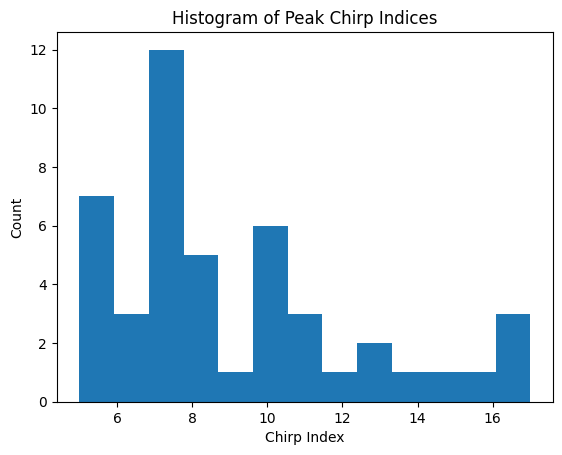

In [43]:
# get the distribution of chirp_idx for peak chirps
peak_chirp_indices = [chirp_idx for (file_id, chirp_idx) in peak_files]
print("mean peak chirp index:", np.mean(peak_chirp_indices), "median peak chirp index:", np.median(peak_chirp_indices))
plt.hist(peak_chirp_indices, bins=(max(peak_chirp_indices) - min(peak_chirp_indices) + 1))
plt.title("Histogram of Peak Chirp Indices")
plt.xlabel("Chirp Index")
plt.ylabel("Count");

In [44]:
# for every row in df_tightness where peak_detected is True, calculate the distance in chirp_idx to the previous peak_detected True row with the same file_id
df_tightness['distance_to_prev_peak'] = np.nan
for file_id in df_tightness['file_id'].unique():
    sel = df_tightness[df_tightness['file_id'] == file_id].sort_values('chirp_idx')
    prev_peak_chirp_idx = None
    for idx, row in sel.iterrows():
        if row['peak_detected']:
            if prev_peak_chirp_idx is not None:
                distance = row['chirp_idx'] - prev_peak_chirp_idx
                df_tightness.loc[idx, 'distance_to_prev_peak'] = distance
            prev_peak_chirp_idx = row['chirp_idx']
df_tightness

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak
0,1039,10,0.627979,0.395632,1.795447e+13,0.572383,1.463103e+15,3.830414,False,False,False,NaN
1,1039,9,0.643326,0.369565,1.741661e+14,0.603087,2.562899e+15,4.255110,False,False,False,NaN
2,1039,8,0.624624,0.405090,3.443769e+12,0.687735,6.128022e+13,4.635760,False,False,True,NaN
3,1039,7,0.637144,0.382486,2.627954e+15,0.749664,1.876812e+15,4.953883,False,False,False,NaN
4,1039,6,0.632494,0.389968,3.496682e+14,0.650974,4.553825e+13,7.764713,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
553,1090,10,0.637700,0.383417,4.910904e+13,0.596325,1.576547e+13,4.464012,False,False,False,NaN
554,1090,9,0.645946,0.372097,2.870314e+15,0.933184,1.777334e+15,6.799188,False,False,False,NaN
555,1090,8,0.640552,0.379333,9.949279e+13,0.578274,1.699297e+13,3.948870,False,False,False,NaN
556,1090,7,0.665639,0.329097,2.713251e+14,0.830721,7.394526e+14,5.383677,False,False,True,NaN


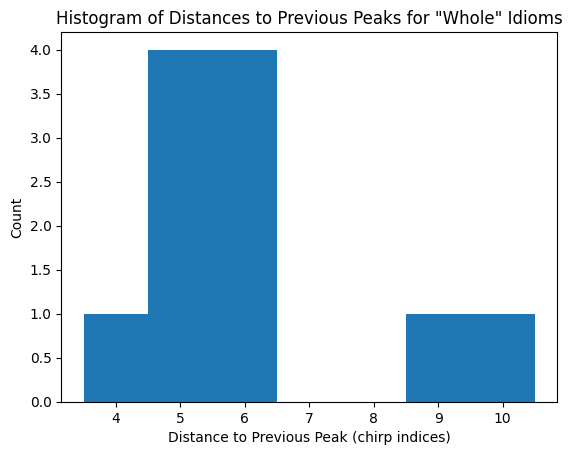

In [45]:
distance_values = df_tightness['distance_to_prev_peak'].dropna()
plt.hist(distance_values, bins=(np.arange(min(distance_values), max(distance_values) + 2) - 0.5))
plt.title("Histogram of Distances to Previous Peaks for \"Whole\" Idioms")
plt.xlabel("Distance to Previous Peak (chirp indices)")
plt.ylabel("Count");

In [46]:
# extract the rows of df_tightness corresponding to files that have 2 or more peaks
# this corresponds to the sequences that contain one whole idiom
from collections import Counter
file_id_counts = Counter([file_id for (file_id, chirp_idx) in peak_files])
files_with_multiple_peaks = [file_id for file_id, count in file_id_counts.items() if count >= 2]
df_tightness_multiple_peaks = df_tightness[df_tightness['file_id'].isin(files_with_multiple_peaks)]
print("There are", len(files_with_multiple_peaks), "out of", len(file_id_counts), "files with 2+ peaks.")
df_tightness_multiple_peaks

There are 10 out of 35 files with 2+ peaks.


,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak
74,1048,18,0.624017,0.414495,1.024058e+13,0.505365,1.618460e+12,3.781436,False,False,False,NaN
75,1048,17,0.582169,0.489043,3.387979e+11,0.485588,1.852689e+13,3.528526,True,False,True,6.0
76,1048,16,0.628750,0.396295,2.860320e+12,1.066063,9.515631e+11,7.316529,False,False,False,NaN
77,1048,15,0.658442,0.347015,7.143536e+13,0.726664,9.859215e+13,7.657079,False,False,False,NaN
78,1048,14,0.660157,0.346321,1.078618e+15,0.312421,2.500048e+16,2.417577,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
545,1089,8,0.645692,0.370356,6.405848e+14,1.080737,4.279678e+13,7.243141,False,False,False,NaN
546,1089,7,0.695231,0.295064,1.277572e+19,0.996162,1.226377e+18,7.380237,False,False,False,NaN
547,1089,6,0.625190,0.410469,6.723417e+13,0.847113,2.262270e+13,5.602453,False,False,False,NaN
548,1089,5,0.591208,0.472050,2.678625e+12,0.410212,5.339667e+12,2.861210,True,False,True,NaN


In [47]:
# from df_tightness_multiple_peaks, between every two peaks for the same file_id, extract the sequence of indices into a new array
# each sequence corresponds to one whole idiom
whole_idiom_sequences = []
for file_id in df_tightness_multiple_peaks['file_id'].unique():
    sequence = df_tightness_multiple_peaks[df_tightness_multiple_peaks['file_id'] == file_id]
    peak_indices = sequence[sequence['peak_detected'] == True].index.tolist()
    # print(peak_indices)
    for i in range(len(peak_indices) - 1):
        start_idx = peak_indices[i]
        end_idx = peak_indices[i + 1]
        # unless it is the last peak, exclude the end_idx in the sequence
        if i < len(peak_indices) - 2:
            end_idx -= 1
        seq = sequence.loc[start_idx:end_idx]
        whole_idiom_sequences.append(seq.index.tolist())

whole_idiom_sequences

[[75, 76, 77, 78, 79, 80, 81],
 [291, 292, 293, 294, 295, 296],
 [315, 316, 317, 318, 319, 320],
 [328, 329, 330, 331, 332, 333, 334, 335, 336, 337],
 [349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359],
 [366, 367, 368, 369, 370, 371, 372],
 [382, 383, 384, 385, 386],
 [437, 438, 439, 440, 441, 442, 443],
 [462, 463, 464, 465, 466],
 [467, 468, 469, 470, 471, 472],
 [542, 543, 544, 545, 546, 547, 548]]

In [48]:
# transform whole_idiom_sequences to be just the start and end chirp_idx values
whole_idiom_sequences_np = whole_idiom_sequences.copy()
for i in range(len(whole_idiom_sequences)):
    seq = whole_idiom_sequences[i]
    start_chirp_idx = seq[0]
    end_chirp_idx = seq[-1]
    whole_idiom_sequences_np[i] = (start_chirp_idx, end_chirp_idx)
# save the whole_idiom_sequences as a npy file
np.save("whole_idiom_sequences.npy", whole_idiom_sequences_np)
whole_idiom_sequences_np

[(75, 81),
 (291, 296),
 (315, 320),
 (328, 337),
 (349, 359),
 (366, 372),
 (382, 386),
 (437, 443),
 (462, 466),
 (467, 472),
 (542, 548)]

In [49]:
# from df_tightness, extract the sequence of indices from the start to the first peak for each file_id that has a peak
onset_idiom_sequences = []
for file_id in df_tightness['file_id'].unique():
    sequence = df_tightness[df_tightness['file_id'] == file_id]
    peak_indices = sequence[sequence['peak_detected'] == True].index.tolist()
    # print(peak_indices)
    if len(peak_indices) == 0:
        continue
    start_idx = 0
    end_idx = peak_indices[0] - 1 # exclude the peak itself (it belongs to the next idiom)
    seq = sequence.loc[start_idx:end_idx]
    onset_idiom_sequences.append(seq.index.tolist())

onset_idiom_sequences

[[0, 1],
 [15],
 [21, 22, 23, 24, 25, 26, 27, 28, 29],
 [32, 33, 34, 35, 36, 37, 38],
 [53, 54, 55, 56, 57, 58, 59],
 [74],
 [89, 90],
 [115, 116],
 [121, 122],
 [134, 135, 136, 137, 138, 139, 140, 141],
 [158, 159, 160, 161, 162],
 [170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180],
 [188, 189, 190, 191, 192, 193, 194, 195, 196],
 [237, 238, 239],
 [254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266],
 [271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283],
 [288, 289, 290],
 [300, 301],
 [304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314],
 [327],
 [342, 343, 344, 345, 346, 347, 348],
 [361, 362, 363, 364, 365],
 [376, 377, 378, 379, 380, 381],
 [392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403],
 [407, 408, 409, 410, 411],
 [417, 418],
 [432, 433, 434, 435, 436],
 [447, 448, 449, 450, 451, 452, 453, 454, 455],
 [461],
 [476, 477],
 [481, 482, 483, 484],
 [492, 493, 494, 495, 496, 497, 498, 499],
 [516, 517],
 [535, 536, 537, 538, 539, 540, 

In [50]:
# print the number of rows in df_tightness where peak_detected is True and large_range is True
print(df_tightness[(df_tightness['peak_detected'] == True) & (df_tightness['large_range'] == True)].shape[0], "chirps are peak and large range")
# print the number of rows in df_tightness where peak_detected is True
print(df_tightness[df_tightness['peak_detected'] == True].shape[0], "chirps are peak detected")
# print the number of rows in df_tightness where large_range is True
print(df_tightness[df_tightness['large_range'] == True].shape[0], "chirps are large range")
print("There are", df_tightness.shape[0], "total chirps")
df_tightness.sort_values(['peak_detected', 'large_range'], ascending=[False, False])

4 chirps are peak and large range
46 chirps are peak detected
71 chirps are large range
There are 558 total chirps


,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak
39,1043,10,0.663310,0.341367,8.881454e+17,0.457202,8.974009e+16,3.470655,False,True,True,NaN
163,1056,10,0.669719,0.330189,1.187624e+17,1.347421,7.883651e+15,9.615600,False,True,True,NaN
267,1065,7,0.654756,0.358709,1.264370e+17,0.585277,1.842129e+16,4.270408,False,True,True,NaN
419,1079,16,0.611351,0.433855,1.401184e+11,0.981607,1.044001e+11,8.880075,False,True,True,NaN
2,1039,8,0.624624,0.405090,3.443769e+12,0.687735,6.128022e+13,4.635760,False,False,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
552,1090,11,0.654011,0.352008,1.521386e+14,0.666101,2.100679e+13,4.705857,False,False,False,NaN
553,1090,10,0.637700,0.383417,4.910904e+13,0.596325,1.576547e+13,4.464012,False,False,False,NaN
554,1090,9,0.645946,0.372097,2.870314e+15,0.933184,1.777334e+15,6.799188,False,False,False,NaN
555,1090,8,0.640552,0.379333,9.949279e+13,0.578274,1.699297e+13,3.948870,False,False,False,NaN


In [51]:
# for each file_id where peak_detected is True, use split_filename_to_id_path to find each filename
filename_to_id_df = pd.read_csv(filename_to_id_path)
peak_filenames = []
for (file_id, chirp_idx) in peak_files:
    matching_rows = filename_to_id_df[filename_to_id_df['file_id'] == file_id]
    if not matching_rows.empty:
        filename = matching_rows.iloc[0]['Filename']
        # use unscaled_truth_list_0 to find the TimeInFile for this file_id and chirp_idx
        time_in_file = unscaled_truth_list_0[(unscaled_truth_list_0['chirp_idx'] == chirp_idx) & \
                                             (unscaled_truth_list_0['file_id'] == file_id)]['TimeInFile'].iloc[0]
        peak_filenames.append((filename, file_id, chirp_idx, time_in_file))
peak_filenames

[('lake2-20220208_202138_2secs.wav', 1039, 8, 1810.0000399084054),
 ('lake2-20220208_202756_2secs.wav', 1041, 8, 1038.9999969805008),
 ('lake2-20220208_202800_2secs.wav', 1042, 5, 419.9999880849087),
 ('lake2-20220208_202925_2secs.wav', 1043, 10, 778.0000050632432),
 ('lake2-20220208_203219_2secs.wav', 1045, 7, 776.9999990343105),
 ('lake2-20220208_204602_2secs.wav', 1048, 11, 1090.9999973587944),
 ('lake2-20220208_204602_2secs.wav', 1048, 17, 1766.0000071821032),
 ('lake2-20220208_204604_2secs.wav', 1049, 7, 958.9999955031964),
 ('lake2-20220208_211343_2secs.wav', 1052, 7, 808.9999995225708),
 ('lake2-20220208_211543_2secs.wav', 1053, 14, 1394.9999938840233),
 ('lake2-20220208_211913_2secs.wav', 1054, 6, 1301.9999824098861),
 ('lake2-20220208_213709_2secs.wav', 1056, 10, 1365.99998101501),
 ('lake2-20220208_213939_2secs.wav', 1057, 5, 918.0000003567093),
 ('lake2-20220208_215735_2secs.wav', 1059, 10, 1104.0000098194341),
 ('lake2-20220208_220331_2secs.wav', 1063, 7, 957.9999986630999)

In [52]:
peak_indices = [(df_tightness.index[(df_tightness['file_id'] == file_id) & (df_tightness['chirp_idx'] == chirp_idx)][0]) for (file_id, chirp_idx) in peak_files]

In [53]:
# Plot each sequence of chirps for the test set
from tqdm import tqdm

# test_range = range(4951, 5187)
# save_folder = "../../bats_transformer/plots/july_daytime_new_mask_11_5"
# if not os.path.exists(save_folder):
#     os.mkdir(save_folder)
# for fid in tqdm(test_range):
#     try:
#         plot_tightness_by_file(fid, show=False, save_filename=f"{save_folder}/cluster_plot_{int(fid)}")
#     except ValueError as e:
#         print(e)

This next section looks at the peak points to generate files corresponding to the peak contexts and peak chirps.
It will also organize the data into "idioms" based on the peak locations.
An idiom is defined as starting from the beginning of the file or from a peak chirp to the chirp before the next peak.

In [54]:
sys.path.append('../../bats_transformer/spacetimeformer')
import spacetimeformer as stf
# import spacetimeformer.spacetimeformer
import sys
sys.path.append('../../bats_transformer')
from data.bats_dataset import *
# from spacetimeformer.data.datamodule import DataModule
# print(sys.modules.keys())


ignore_cols = ["FreqLedge","AmpK@end", "Fc", "FBak15dB  ", "FBak32dB", "EndF", "FBak20dB", "LowFreq", "Bndw20dB", 
               "CallsPerSec", "EndSlope", "SteepestSlope", "StartSlope", "Bndw15dB", "HiFtoUpprKnSlp", "HiFtoKnSlope", 
               "DominantSlope", "Bndw5dB", "PreFc500", "PreFc1000", "PreFc3000", "KneeToFcSlope", "TotalSlope", 
               "PreFc250", "CallDuration", "CummNmlzdSlp", "DurOf32dB", "SlopeAtFc", "LdgToFcSlp", "DurOf20dB", "DurOf15dB", 
               "TimeFromMaxToFc", "KnToFcDur", "HiFtoFcExpAmp", "AmpKurtosis", "LowestSlope", "KnToFcDmp", "HiFtoKnExpAmp", 
               "DurOf5dB", "KnToFcExpAmp", "RelPwr3rdTo1st", "LnExpB_StartAmp", "Filter", "HiFtoKnDmp", "LnExpB_EndAmp", 
               "HiFtoFcDmp", "AmpSkew", "LedgeDuration", "KneeToFcResidue", "PreFc3000Residue", "AmpGausR2", "PreFc1000Residue", 
               "Amp1stMean", "LdgToFcExp", "FcMinusEndF", "Amp4thMean", "HiFtoUpprKnExp", "HiFtoKnExp", "KnToFcExp", "UpprKnToKnExp", 
               "Kn-FcCurviness", "Amp2ndMean", "Quality", "HiFtoFcExp", "LnExpA_EndAmp", "RelPwr2ndTo1st", "LnExpA_StartAmp", 
               "HiFminusStartF", "Amp3rdMean", "PreFc500Residue", "Kn-FcCurvinessTrndSlp", "PreFc250Residue", "AmpVariance", "AmpMoment", 
               "meanKn-FcCurviness", "MinAccpQuality", "AmpEndLn60ExpC", "AmpStartLn60ExpC", "Preemphasis", "MaxSegLnght" ,"Max#CallsConsidered" ]
ignore_cols += ["Filename", "NextDirUp", 'Path', 'Version', 'Filter', 'Preemphasis', 'MaxSegLnght', "ParentDir", "file_id", "chirp_idx", "split"]

data_module = stf.data.DataModule(
    datasetCls = BatsCSVDataset,
    dataset_kwargs = {
        "root_path": "../../bats_transformer/data/july_daytime_chunked_quantile/splits",
        "prefix": "split",
        "ignore_cols": ignore_cols,
        "time_col_name": "TimeIndex",
        "val_split": 0.05,
        "test_split": 0.05,
        "context_points": None,
        "target_points": 1,
        "random_seed": 31
    },
    batch_size=64,
    workers=4,
)

test_data = data_module.test_dataloader()

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [55]:
low_conf_contexts = []
low_conf_truths = []
batch_num = 0
for batch in tqdm(test_data):
    x_t, x_c, y_t, y_c = batch
    # if the idx of the data point is in one of [low_confidence_indices, peak_indices], save the context and truth
    batch_indices = np.array(range(x_c.shape[0])) + batch_num * data_module.batch_size
    for i, idx in enumerate(batch_indices):
        # if idx in low_confidence_indices:
        if idx in peak_indices:
            low_conf_contexts.append(x_c[i].cpu().numpy())
            low_conf_truths.append(y_c[i].cpu().numpy())
    batch_num += 1


100%|██████████| 22/22 [00:05<00:00,  4.04it/s]


In [56]:
low_conf_contexts = np.array(low_conf_contexts)
low_conf_truths = np.array(low_conf_truths)
np.save(f"{output_folder}/peak_contexts.npy", low_conf_contexts)
np.save(f"{output_folder}/peak_truths.npy", low_conf_truths)

In [57]:
low_conf_contexts.shape, low_conf_truths.shape

((46, 21, 32), (46, 1, 32))

Here are a couple of old attempts to find confidence peaks:

In [58]:
# def find_tightness_drops(
#     file_id,
#     df=df_tightness,
#     window=2,
#     method="relative",
#     rel_threshold=0.5,
#     z_thresh=2.0,
#     min_abs_drop=None,
#     min_neighbors=1,
#     return_type="chirp_idx",
# ):
#     """
#     Find chirp_idx within a file where tightness shows a significant decrease
#     compared to surrounding chirp_idx values.

#     Parameters
#     - file_id: value in df['file_id'] to select rows for.
#     - df: dataframe with columns ['file_id','chirp_idx','tightness'] (defaults to df_tightness).
#     - window: number of neighbors before and after to consider (int).
#     - method: one of
#         * 'relative'   -> (local_mean - t) / (local_mean) >= rel_threshold
#         * 'zscore'     -> (local_mean - t) / local_std >= z_thresh
#         * 'absolute'   -> (local_mean - t) >= min_abs_drop
#     - rel_threshold: fraction threshold for 'relative' method (default 0.5).
#     - z_thresh: threshold in sigma for 'zscore' method (default 2.0).
#     - min_abs_drop: minimum absolute drop used by 'absolute' method (if None, must be provided)
#     - min_neighbors: minimum number of neighbor points required to evaluate (default 1).
#     - return_type: 'chirp_idx' (list), 'df' (rows with diagnostics), or 'indices' (original df indices).

#     Returns
#     - depending on return_type
#     """
#     sel = df[df["file_id"] == file_id].copy()
#     if sel.empty:
#         raise ValueError(f"No rows found for file_id={file_id}")

#     # keep original dataframe index so we can return indices if requested
#     sel = sel.sort_values("chirp_idx").reset_index().rename(columns={"index": "orig_index"})
#     t = sel["tightness"].astype(float).values
#     n = len(t)
#     eps = 1e-12

#     results = []
#     for i in range(n):
#         # neighbor window: exclude current i
#         lo = max(0, i - window)
#         hi = min(n, i + window + 1)
#         neighbor_idx = list(range(lo, i)) + list(range(i + 1, hi))
#         if len(neighbor_idx) < min_neighbors:
#             results.append((i, False, np.nan, np.nan, np.nan))
#             continue

#         neigh_vals = t[neighbor_idx]
#         local_mean = float(np.nanmean(neigh_vals))
#         local_med = float(np.nanmedian(neigh_vals))
#         local_std = float(np.nanstd(neigh_vals, ddof=0))

#         drop_amount = local_mean - t[i]
#         drop_fraction = drop_amount / (local_mean + eps)
#         drop_z = (local_mean - t[i]) / (local_std + eps)

#         is_drop = False
#         if method == "relative":
#             is_drop = (drop_fraction >= rel_threshold)
#         elif method == "zscore":
#             is_drop = (drop_z >= z_thresh)
#         elif method == "absolute":
#             if min_abs_drop is None:
#                 raise ValueError("min_abs_drop must be provided for method='absolute'")
#             is_drop = (drop_amount >= min_abs_drop)
#         else:
#             raise ValueError("method must be one of: 'relative', 'zscore', 'absolute'")

#         results.append((i, bool(is_drop), drop_amount, drop_fraction, drop_z))

#     res_df = pd.DataFrame(
#         results, columns=["pos", "is_drop", "drop_amount", "drop_fraction", "drop_z"]
#     )
#     # attach chirp_idx and original index and tightness
#     res_df["chirp_idx"] = sel["chirp_idx"].values
#     res_df["tightness"] = sel["tightness"].values
#     res_df["orig_index"] = sel["orig_index"].values

#     if return_type == "df":
#         return res_df.loc[res_df["is_drop"]].reset_index(drop=True)
#     elif return_type == "chirp_idx":
#         return res_df.loc[res_df["is_drop"], "chirp_idx"].tolist()
#     elif return_type == "indices":
#         return res_df.loc[res_df["is_drop"], "orig_index"].tolist()
#     else:
#         raise ValueError("return_type must be one of: 'df', 'chirp_idx', 'indices'")

# # Example usage:
# drops = find_tightness_drops(sample_file_id, method='relative', rel_threshold=0.02, window=2, return_type='df')
# drops

In [59]:
# def find_tightness_outliers(
#     file_id,
#     df=df_tightness,
#     method="iqr",
#     iqr_multiplier=1.5,
#     z_thresh=3.0,
#     return_type="df",
# ):
#     """
#     Identify chirp_idx rows for a given file_id whose 'tightness' is an outlier.

#     Parameters
#     - file_id: value in df['file_id'] to select rows for.
#     - df: dataframe with columns ['file_id','chirp_idx','tightness'] (defaults to df_tightness).
#     - method: 'iqr' (default), 'zscore', or 'modified_zscore' (based on MAD).
#     - iqr_multiplier: multiplier for IQR rule (only for method='iqr').
#     - z_thresh: threshold for zscore / modified zscore (absolute value).
#     - return_type: 'df' (returns DataFrame with an 'is_outlier' column),
#                    'chirp_idx' (returns list of chirp_idx values flagged),
#                    'indices' (returns DataFrame indices).

#     Returns
#     - depending on return_type
#     """
#     sel = df[df["file_id"] == file_id].copy()
#     if sel.empty:
#         raise ValueError(f"No rows found for file_id={file_id}")

#     x = sel["tightness"].astype(float)

#     if method == "iqr":
#         q1 = np.nanpercentile(x, 25)
#         q3 = np.nanpercentile(x, 75)
#         iqr = q3 - q1
#         lower = q1 - iqr_multiplier * iqr
#         upper = q3 + iqr_multiplier * iqr
#         is_outlier = (x < lower) | (x > upper)
#     elif method == "zscore":
#         mu = np.nanmean(x)
#         sigma = np.nanstd(x, ddof=0)
#         if sigma == 0:
#             is_outlier = np.zeros_like(x, dtype=bool)
#         else:
#             z = (x - mu) / sigma
#             is_outlier = np.abs(z) > z_thresh
#     elif method == "modified_zscore":
#         med = np.nanmedian(x)
#         mad = np.nanmedian(np.abs(x - med))
#         if mad == 0:
#             is_outlier = np.zeros_like(x, dtype=bool)
#         else:
#             mod_z = 0.6745 * (x - med) / mad
#             is_outlier = np.abs(mod_z) > z_thresh
#     else:
#         raise ValueError("method must be one of: 'iqr', 'zscore', 'modified_zscore'")

#     sel["is_outlier"] = is_outlier.values

#     if return_type == "df":
#         return sel
#     elif return_type == "chirp_idx":
#         return sel.loc[sel["is_outlier"], "chirp_idx"].tolist()
#     elif return_type == "indices":
#         return sel.index[sel["is_outlier"]].tolist()
#     else:
#         raise ValueError("return_type must be one of: 'df', 'chirp_idx', 'indices'")
    
# # Example:
# outliers = find_tightness_outliers(sample_file_id, method="iqr", return_type="df")
# outliers

In this section, I investigate potential patterns in the identified "low-confidence" predictions through clustering.

In [60]:
unscaled_truth_list_0

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
0,1952.000011,66.0,96.158684,44.598516,61.437991,65.504656,70.148691,34.431935,96.158684,70.148691,...,16527.130672,13056.246133,5778.950009,27.786076,27.970411,242.288106,260.169814,5.991460,1039,10
1,1886.000008,77.0,86.049614,33.516771,64.294329,47.009236,63.138954,52.091316,86.049614,63.138954,...,21522.557313,14748.268862,18103.736119,27.475878,26.572488,256.128678,268.629707,3.079585,1039,9
2,1810.000040,78.0,77.448164,27.228307,63.293010,42.370659,57.023440,57.906567,77.448164,57.023440,...,14751.228358,19402.585602,11857.859443,18.352053,17.652188,181.987201,185.056130,4.191730,1039,8
3,1291.000009,115.0,98.870084,47.086235,64.084846,56.225458,65.463989,52.347840,98.870084,65.463989,...,8978.939218,14443.475086,10812.267166,30.280464,25.923295,307.438836,273.939478,5.356962,1039,7
4,1175.999992,85.0,89.439404,36.285696,60.602086,60.615042,59.861959,63.501472,89.439404,66.890811,...,12232.084651,14788.244810,9915.377682,17.945954,22.234256,163.756514,203.706458,1.157496,1039,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,65.033890,...,4887.441377,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090,10
554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,52.235091,...,17695.370816,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090,9
555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,57.253009,...,13915.889054,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090,8
556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,59.687491,...,13638.972049,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090,7


In [61]:
# get all the features that contain "Amp" in their name from unscaled_truth_list_0
amp_features = [col for col in unscaled_truth_list_0.columns if "Amp" in col]
amp_features

['PrcntMaxAmpDur',
 'HiFtoUpprKnAmp',
 'HiFtoKnAmp',
 'HiFtoFcAmp',
 'UpprKnToKnAmp',
 'KnToFcAmp',
 'LdgToFcAmp',
 'Amp1stQrtl',
 'Amp2ndQrtl',
 'Amp3rdQrtl',
 'Amp4thQrtl',
 'AmpK@start']

In [62]:
# use sklearn hdbscan to cluster all chirps found in unscaled_truth_list_0
from sklearn import cluster
import umap

NO_AMP = 2 # set to 0 to keep all amp features, 1 to remove [Amp1stQrtl, Amp2ndQrtl, Amp3rdQrtl, Amp4thQrtl], 2 to remove all amp features

chirp_data = unscaled_truth_list_0.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy()

# remove columns that contain "Amp" in their name if NO_AMP is set
if NO_AMP == 1:
    amp_indices = [i - 1 for i, col in enumerate(unscaled_truth_list_0.columns) if col in ["Amp1stQrtl", "Amp2ndQrtl", "Amp3rdQrtl", "Amp4thQrtl"]]
    chirp_data = np.delete(chirp_data, amp_indices, axis=1)
elif NO_AMP == 2:
    amp_indices = [i - 1 for i, col in enumerate(unscaled_truth_list_0.columns) if "Amp" in col]
    chirp_data = np.delete(chirp_data, amp_indices, axis=1)

chirp_data_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(chirp_data)

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [63]:
chirp_data_embedded_df = pd.DataFrame(chirp_data_embedded, columns=['UMAP1', 'UMAP2'])
chirp_data_embedded_df

,UMAP1,UMAP2
0,6.494684,8.999373
1,5.857782,9.107106
2,5.990413,12.535196
3,6.970911,7.051557
4,7.435813,12.714695
...,...,...
553,5.083922,15.409432
554,5.329377,17.758030
555,4.141896,17.372097
556,4.568326,17.412100


In [64]:
# for each sequence in whole_idiom_sequences, use chirp_data_embedded_df to get the sequence of 2D UMAP points
whole_idiom_umap_sequences = []
for seq_indices in whole_idiom_sequences:
    seq_umap_points = chirp_data_embedded_df.iloc[seq_indices].to_numpy()
    whole_idiom_umap_sequences.append(seq_umap_points)
whole_idiom_umap_sequences

[array([[ 6.7375503, 11.970169 ],
        [ 3.6286879, 16.345903 ],
        [ 6.3578963,  9.88019  ],
        [ 7.2744865, 12.286471 ],
        [ 7.3207197,  5.2857294],
        [ 6.5343513, 16.982986 ],
        [ 7.672413 , 13.738741 ]], dtype=float32),
 array([[ 7.475876 ,  4.8644443],
        [ 7.011548 , 14.928961 ],
        [ 4.767079 , 17.611515 ],
        [ 7.473406 , 13.937633 ],
        [ 6.7999043,  6.787876 ],
        [ 5.491491 , 10.2533045]], dtype=float32),
 array([[ 6.927141 ,  9.438061 ],
        [ 5.5490913, 17.740932 ],
        [ 4.2153273, 17.080359 ],
        [ 4.739114 , 14.555115 ],
        [ 6.991926 , 13.53061  ],
        [ 7.5450816,  4.8722653]], dtype=float32),
 array([[ 6.9438004,  6.7114415],
        [ 6.567627 , 16.525585 ],
        [ 6.502026 ,  9.933648 ],
        [ 7.9806767, 13.946806 ],
        [ 7.4795995,  5.3504705],
        [ 6.677727 , 10.184797 ],
        [ 5.804675 ,  9.930346 ],
        [ 7.362943 , 11.606077 ],
        [ 7.4982457,  4.876947 

First, we want to see how many clusters there should be.

In [65]:
from gap_statistic import OptimalK
from scipy.spatial.distance import cdist
from kneed import KneeLocator
from scipy.cluster.hierarchy import fcluster
from hdbscan import HDBSCAN
from sklearn.decomposition import PCA

n_clusters = dict()

In [66]:
# calculate gap statistic using optimalK
optimalK = OptimalK(n_jobs=4, parallel_backend='joblib')
optimal_k_n_clusters = optimalK(chirp_data_embedded, cluster_array=np.arange(1, 50))

n_clusters["gap_statistic"] = optimal_k_n_clusters
# get the index of the first row in optimalK.gap_df["diff"] that is positive
first_positive_diff_idx = optimalK.gap_df[optimalK.gap_df["diff"] > 0].index[0]
n_clusters["diff_statistic"] = first_positive_diff_idx + 1 # add 1 because index starts at 0
n_clusters

{'gap_statistic': 37, 'diff_statistic': 5}

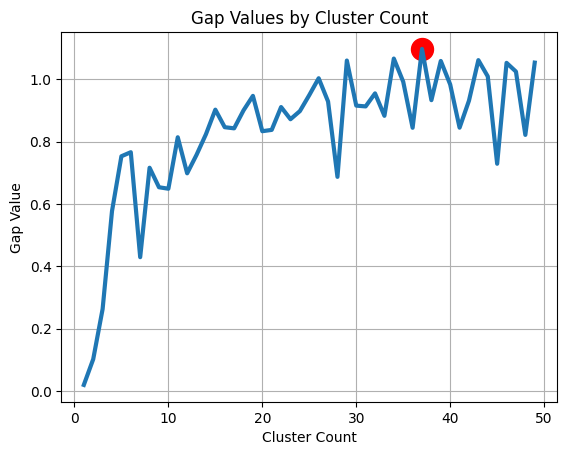

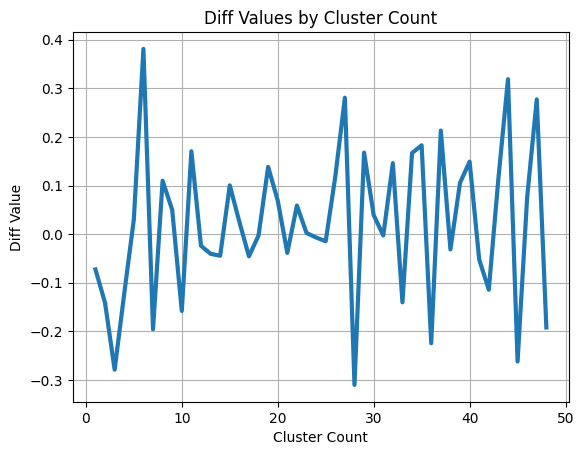

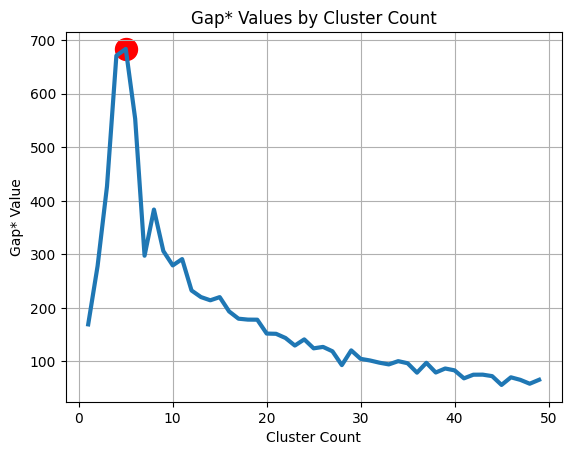

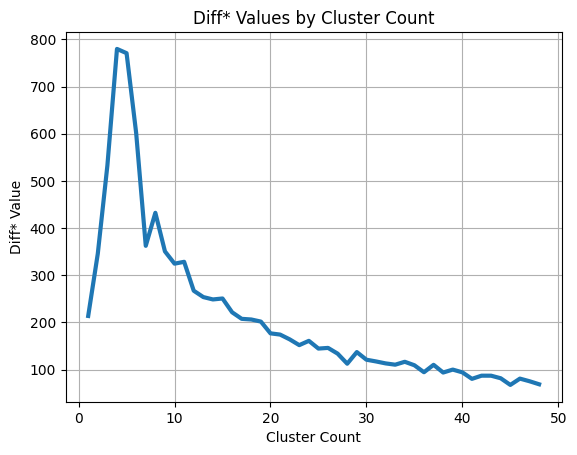

In [67]:
# plt.plot(optimalK.gap_df.n_clusters, optimalK.gap_df.gap_value)
optimalK.plot_results()

100%|██████████| 49/49 [00:00<00:00, 284.13it/s]


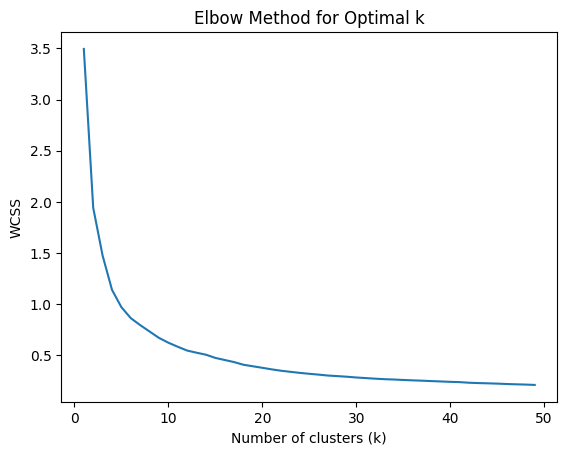

In [68]:
# Use the elbow method to find the number of clusters where the within-cluster sum of squares (WCSS) starts to level off
# Use agglomerative clustering to compute WCSS for k=1 to 50
ELBOW_MIN_K = 1
ELBOW_MAX_K = 50

wcss = []
for i in tqdm(range(ELBOW_MIN_K, ELBOW_MAX_K)):
    agglom = cluster.AgglomerativeClustering(n_clusters=i)
    agglom.fit(chirp_data_embedded)
    labels = agglom.labels_
    centroids = np.array([chirp_data_embedded[labels == j].mean(axis=0) for j in range(i)])
    wcss.append(sum(np.min(cdist(chirp_data_embedded, centroids, 'euclidean'), axis=1)) / chirp_data_embedded.shape[0])
plt.plot(range(ELBOW_MIN_K, ELBOW_MAX_K), wcss)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show();

In [69]:
# identify the elbow point in the WCSS plot using the "knee" method
knee_locator = KneeLocator(range(ELBOW_MIN_K, ELBOW_MAX_K), wcss, curve='convex', direction='decreasing')
elbow_k = knee_locator.knee
n_clusters["elbow_method"] = elbow_k
n_clusters

{'gap_statistic': 37, 'diff_statistic': 5, 'elbow_method': 6}

In [70]:
clustering = "Agglomerative"
NUM_CLUSTERS = n_clusters["elbow_method"]
umap = True

# getting the linkage tree allows us to specify the number of clusters we want afterwards
if clustering == "HDBSCAN":
    if umap:
        hdb = HDBSCAN(min_cluster_size=5, 
                              min_samples=5, 
                              metric="euclidean",
                              max_cluster_size=1000,
                              cluster_selection_epsilon=7e-7,
                             )
        hdb.fit(chirp_data_embedded)
        Z = hdb.single_linkage_tree_.to_numpy()
        chirp_labels = fcluster(Z, NUM_CLUSTERS, criterion='maxclust')
        # chirp_labels = hdb.fit_predict(chirp_data_embedded)
    else: 
        hdb = HDBSCAN(min_cluster_size=5, 
                              min_samples=5, 
                              metric="euclidean",
                              max_cluster_size=1000,
                              cluster_selection_epsilon=2e-4,
                             )
        Z = hdb.fit(chirp_data)
        Z = hdb.single_linkage_tree_.to_numpy()
        chirp_labels = fcluster(Z, NUM_CLUSTERS, criterion='maxclust')
        # chirp_labels = hdb.fit_predict(chirp_data)
elif clustering == "Agglomerative":
    if umap:
        agglomerative = cluster.AgglomerativeClustering(n_clusters=NUM_CLUSTERS,
                                                        # distance_threshold=20,
                                                        linkage="ward",
                                                        )
        chirp_labels = agglomerative.fit_predict(chirp_data_embedded)
    else:
        agglomerative = cluster.AgglomerativeClustering(n_clusters=NUM_CLUSTERS,
                                                        # distance_threshold=100000,
                                                        linkage="ward",
                                                        )
        chirp_labels = agglomerative.fit_predict(chirp_data)
else:
    raise ValueError("clustering must be one of: 'HDBSCAN', 'Agglomerative'")

chirp_labels

array([0, 0, 3, 2, 3, 1, 3, 1, 1, 1, 3, 4, 1, 3, 1, 2, 2, 0, 2, 2, 5, 1,
       1, 4, 4, 1, 1, 5, 0, 5, 0, 0, 1, 3, 0, 2, 1, 0, 3, 5, 1, 3, 2, 3,
       3, 1, 1, 4, 4, 2, 4, 1, 4, 4, 4, 1, 0, 3, 4, 0, 4, 4, 0, 0, 1, 3,
       4, 1, 3, 4, 4, 3, 1, 1, 0, 5, 4, 0, 3, 2, 1, 3, 5, 3, 3, 5, 1, 1,
       0, 3, 1, 4, 4, 1, 1, 3, 0, 0, 1, 5, 0, 2, 0, 3, 0, 5, 1, 5, 1, 1,
       4, 4, 3, 4, 3, 1, 4, 5, 2, 0, 0, 0, 3, 0, 1, 4, 3, 1, 3, 4, 4, 0,
       0, 3, 4, 1, 1, 1, 0, 4, 4, 1, 4, 3, 3, 0, 4, 0, 3, 5, 0, 3, 1, 2,
       1, 5, 3, 0, 4, 1, 4, 1, 4, 0, 1, 1, 1, 1, 1, 1, 4, 4, 4, 5, 5, 4,
       4, 0, 5, 0, 2, 1, 4, 1, 5, 5, 1, 4, 1, 4, 0, 2, 5, 0, 1, 5, 5, 0,
       4, 1, 0, 5, 0, 5, 0, 5, 1, 3, 3, 1, 2, 0, 0, 5, 0, 5, 0, 5, 2, 0,
       2, 0, 3, 1, 2, 3, 0, 0, 3, 1, 3, 4, 5, 2, 5, 0, 1, 4, 0, 3, 0, 2,
       0, 5, 2, 2, 2, 5, 1, 1, 0, 1, 5, 3, 4, 4, 3, 0, 5, 5, 3, 2, 0, 5,
       0, 3, 1, 0, 2, 3, 0, 4, 1, 1, 1, 2, 4, 1, 1, 1, 2, 5, 5, 5, 2, 4,
       3, 1, 0, 0, 5, 2, 1, 4, 3, 2, 0, 0, 4, 3, 0,

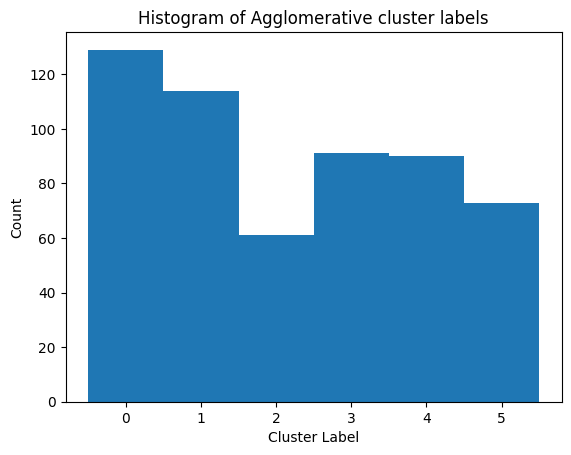

In [71]:
# plot histogram of chirp_labels
plt.hist(chirp_labels, bins=np.arange(chirp_labels.min(), chirp_labels.max() + 2) - 0.5)
plt.title(f"Histogram of {clustering} cluster labels")
plt.xlabel("Cluster Label")
plt.ylabel("Count");

Text(0, 0.5, 'UMAP Component 2')

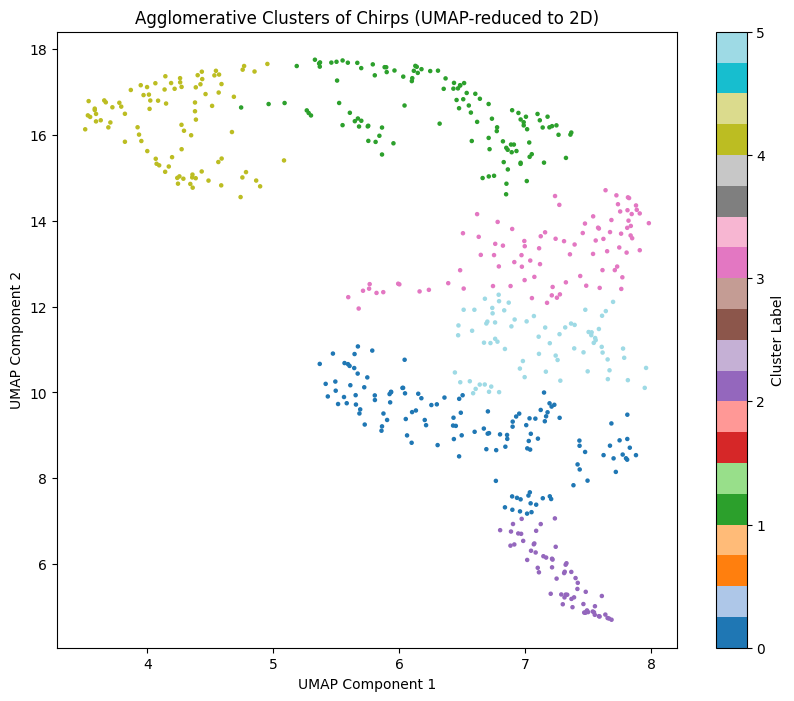

In [72]:
# plot the points in each cluster using PCA for dimensionality reduction
pca = PCA(n_components=2)
chirp_data_2d = pca.fit_transform(chirp_data)
if umap:
    chirp_data_2d = chirp_data_embedded  # use UMAP embedding instead of PCA
# filter out noise points (label == -1)
filtered_chirp_data_2d = chirp_data_2d[chirp_labels != -1]
filtered_chirp_labels = chirp_labels[chirp_labels != -1]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap="tab20", s=5, 
                      vmin=min(chirp_labels), vmax=max(chirp_labels))
plt.title(f"{clustering} Clusters of Chirps ({'UMAP' if umap else 'PCA'}-reduced to 2D)")
plt.colorbar(scatter, label="Cluster Label")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

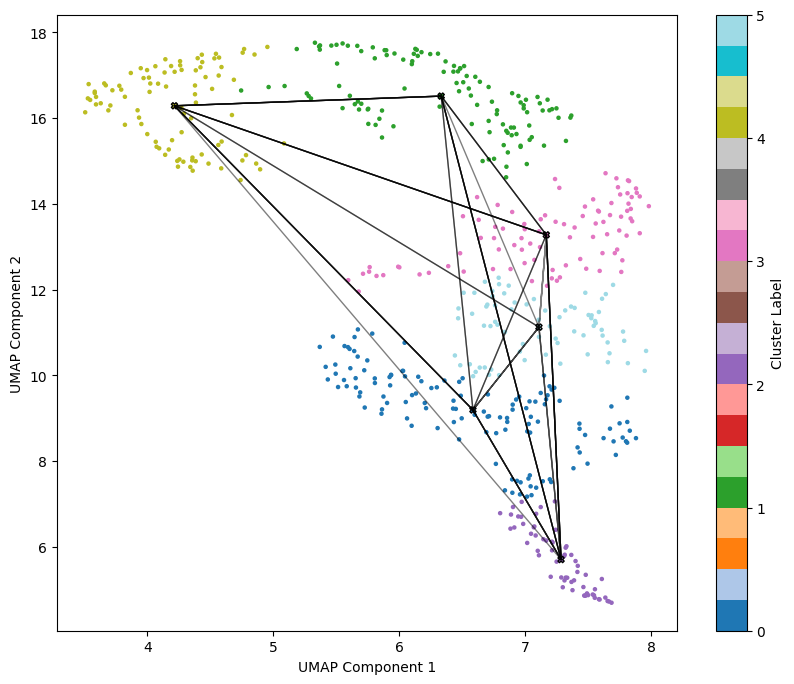

In [73]:
# calculate and plot the centroid of each cluster using the same colors but with a border
unique_labels = np.unique(filtered_chirp_labels)
centroids = []
for label in unique_labels:
    cluster_points = filtered_chirp_data_2d[filtered_chirp_labels == label]
    centroid = cluster_points.mean(axis=0)
    centroids.append(centroid)
centroids = np.array(centroids)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap="tab20", s=5, 
                      vmin=min(chirp_labels), vmax=max(chirp_labels))
plt.scatter(centroids[:, 0], centroids[:, 1], c=unique_labels, cmap="tab20", s=20, edgecolors="black", marker="X", label="Centroids")

whole_idiom_sequence_labels = []
# for each sequence in whole_idiom_umap_sequences, find the centroid of the cluster for each point in the sequence and plot a line connecting them
for seq_points in whole_idiom_umap_sequences:
    seq_labels = []
    for point in seq_points:
        # find the nearest point in filtered_chirp_data_2d to this point
        distances = np.linalg.norm(filtered_chirp_data_2d - point, axis=1)
        nearest_idx = np.argmin(distances)
        seq_labels.append(filtered_chirp_labels[nearest_idx])
    whole_idiom_sequence_labels.append(seq_labels)
    seq_centroids = []
    for label in seq_labels:
        cluster_points = filtered_chirp_data_2d[filtered_chirp_labels == label]
        centroid = cluster_points.mean(axis=0)
        seq_centroids.append(centroid)
    seq_centroids = np.array(seq_centroids)
    # if 0 in seq_labels:
    plt.plot(seq_centroids[:, 0], seq_centroids[:, 1], color="black", linewidth=1, alpha=0.5)

plt.colorbar(scatter, label="Cluster Label")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

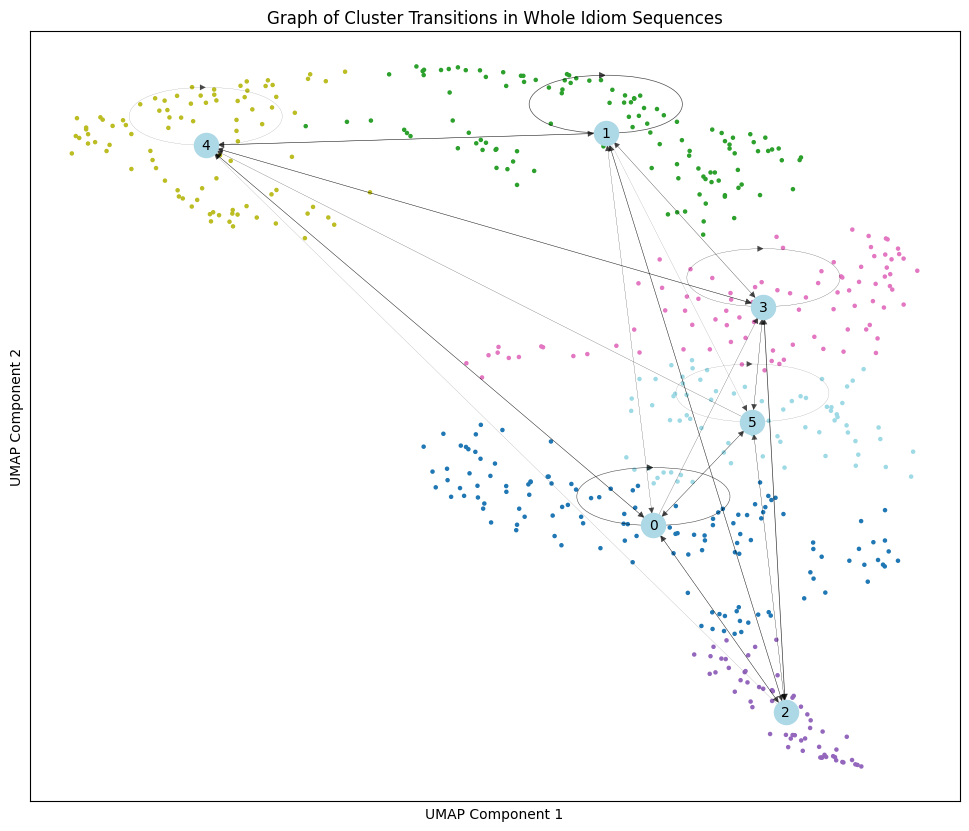

In [74]:
import networkx as nx

G = nx.DiGraph()
for seq in whole_idiom_sequence_labels:
    clusters = seq
    for i in range(len(clusters)-1):
        if G.has_edge(clusters[i], clusters[i+1]):
            G[clusters[i]][clusters[i+1]]['weight'] += 1
        else:
            G.add_edge(clusters[i], clusters[i+1], weight=1)
G.edges

# plot the graph of all chirps in filtered_chirp_data_2d with paths according to whole_idiom_sequence_labels with
# edge weights according to G
plt.figure(figsize=(12, 10))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap="tab20", s=5, 
                      vmin=min(chirp_labels), vmax=max(chirp_labels))
pos = {node: centroids[i] for i, node in enumerate(unique_labels)}
nx.draw_networkx_nodes(G, pos, node_size=300, node_color="lightblue")
edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w * 0.1 for w in weights], alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("Graph of Cluster Transitions in Whole Idiom Sequences")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
plt.show();

In [75]:
# find the most common 3-length label sequences in whole_idiom_sequence_labels
from collections import Counter
N = 3
most_common_ngrams = []
for seq_labels in whole_idiom_sequence_labels:
    for i in range(len(seq_labels) - (N - 1)):
        most_common_ngrams.append(tuple(seq_labels[i:i + N]))
sequence_counts = Counter(most_common_ngrams)
most_common_sequences = sequence_counts.most_common(10)
most_common_sequences

[((0, 3, 2), 2),
 ((2, 1, 4), 2),
 ((4, 3, 2), 2),
 ((3, 2, 0), 2),
 ((0, 0, 2), 2),
 ((4, 1, 1), 2),
 ((1, 1, 1), 2),
 ((4, 0, 0), 2),
 ((5, 4, 0), 1),
 ((4, 0, 3), 1)]

In [76]:
# find the most common prefixes in whole_idiom_sequence_labels
PREFIX_LENGTH = 1

prefix_counts = Counter()
for seq_labels in whole_idiom_sequence_labels:
    if len(seq_labels) >= PREFIX_LENGTH:
        prefix = tuple(seq_labels[:PREFIX_LENGTH])
        prefix_counts[prefix] += 1
most_common_prefixes = prefix_counts.most_common(10)
prefixes_df = pd.DataFrame(most_common_prefixes, columns=['Prefix', 'Count'])
prefixes_df

,Prefix,Count
0,"(5,)",3
1,"(0,)",3
2,"(2,)",2
3,"(1,)",2
4,"(3,)",1


In [77]:
# find the most common suffixes in whole_idiom_sequence_labels
SUFFIX_LENGTH = 1
suffix_counts = Counter()
for seq_labels in whole_idiom_sequence_labels:
    if len(seq_labels) >= SUFFIX_LENGTH:
        suffix = tuple(seq_labels[-SUFFIX_LENGTH:])
        suffix_counts[suffix] += 1
most_common_suffixes = suffix_counts.most_common(10)
suffixes_df = pd.DataFrame(most_common_suffixes, columns=['Suffix', 'Count'])
suffixes_df

,Suffix,Count
0,"(3,)",4
1,"(0,)",3
2,"(2,)",2
3,"(1,)",1
4,"(4,)",1


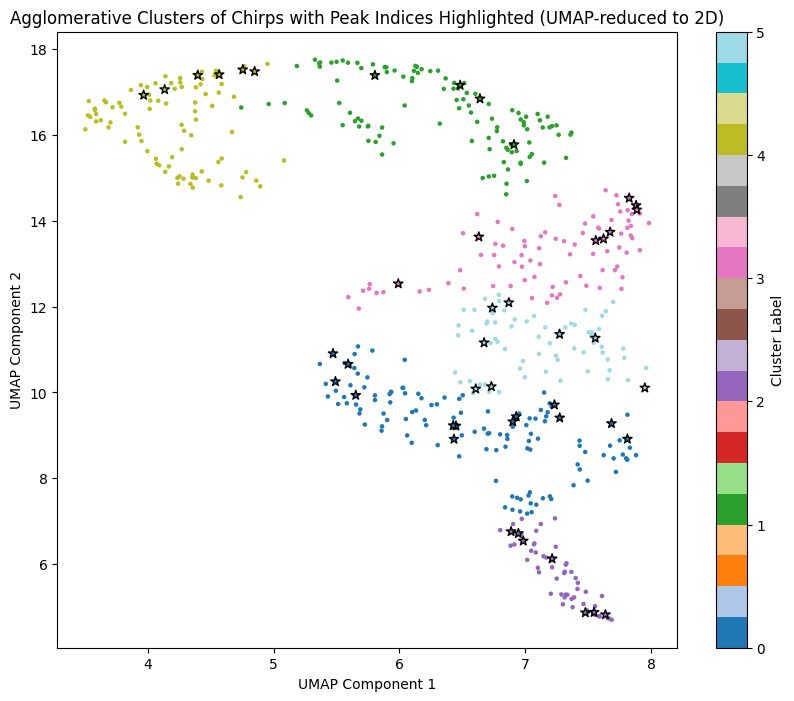

In [78]:
# reproduce the plot but for every point that is in peak_indices, highlight it with a red star
plt.figure(figsize=(10, 8))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap="tab20", s=5,
                      vmin=min(chirp_labels), vmax=max(chirp_labels))
# overlay stars for peak_indices
peak_chirp_clusters = chirp_labels[peak_indices]
scatter_2 = plt.scatter(chirp_data_2d[peak_indices, 0], chirp_data_2d[peak_indices, 1], c=peak_chirp_clusters, 
                        cmap="tab20", edgecolors="black", s=50, marker="*", vmin=min(chirp_labels), vmax=max(chirp_labels))
plt.title(f"{clustering} Clusters of Chirps with Peak Indices Highlighted ({'UMAP' if umap else 'PCA'}-reduced to 2D)")
plt.colorbar(scatter, label="Cluster Label")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
if not umap:
    plt.xlim(-8800, -8000);
    plt.ylim(-1400, -1000);

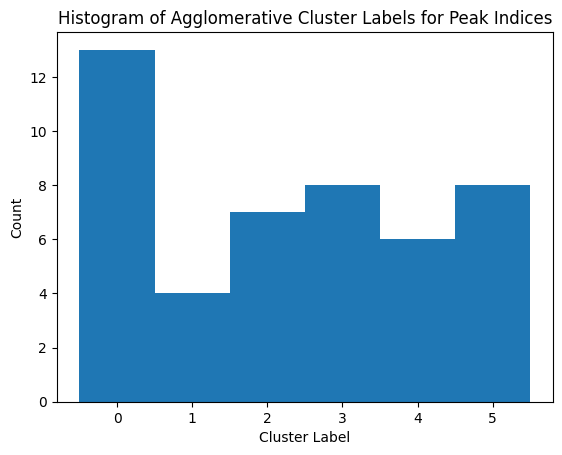

In [79]:
plt.hist(peak_chirp_clusters, bins=np.arange(chirp_labels.min(), chirp_labels.max() + 2) - 0.5)
plt.title(f"Histogram of {clustering} Cluster Labels for Peak Indices")
plt.xlabel("Cluster Label")
plt.ylabel("Count");

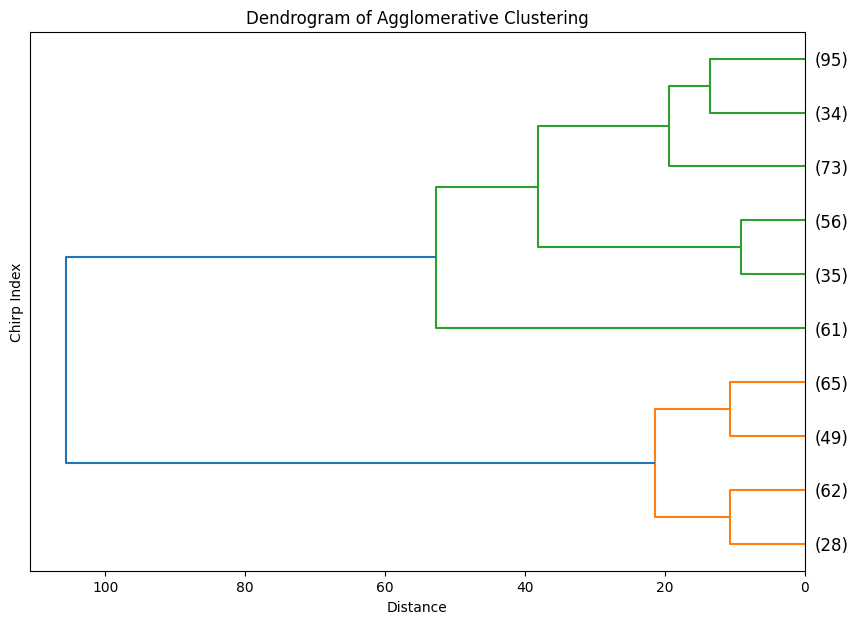

In [80]:
# This is perhaps a separate clustering method, but visualized using a dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# plot dendrogram of agglomerative clustering
linked = linkage(chirp_data_embedded, 'ward')
plt.figure(figsize=(10, 7))
chirp_dendrogram = dendrogram(linked,
           truncate_mode='lastp',
           p=10,
           orientation='left',
        #    distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram of Agglomerative Clustering')
plt.xlabel('Distance')
plt.ylabel('Chirp Index')
plt.show();

In [81]:
# Cut at specific height to get clusters
from scipy.cluster.hierarchy import fcluster
dendrogram_clusters = fcluster(linked, t=10, criterion='maxclust')  # get 10 clusters
dendrogram_clusters

array([10, 10,  7,  5,  7,  3,  6,  3,  3,  3,  7,  2,  3,  6,  3,  5,  5,
        9,  5,  5,  8,  3,  4,  2,  2,  4,  4,  8,  9,  8,  9, 10,  4,  6,
       10,  5,  3, 10,  7,  8,  4,  6,  5,  6,  7,  3,  3,  2,  2,  5,  2,
        4,  2,  2,  2,  3, 10,  7,  1,  9,  2,  1, 10,  9,  4,  7,  1,  4,
        7,  1,  1,  7,  3,  3, 10,  8,  2, 10,  7,  5,  4,  6,  8,  6,  6,
        8,  4,  3, 10,  6,  3,  2,  2,  3,  4,  7, 10, 10,  3,  8,  9,  5,
        9,  7, 10,  8,  4,  8,  4,  4,  2,  1,  6,  2,  7,  4,  2,  8,  5,
       10,  9, 10,  7, 10,  4,  2,  7,  4,  6,  1,  1, 10, 10,  6,  2,  4,
        4,  4, 10,  1,  2,  4,  2,  7,  7, 10,  2, 10,  7,  8,  9,  6,  4,
        5,  4,  8,  7, 10,  2,  3,  1,  3,  1, 10,  3,  3,  3,  3,  3,  3,
        2,  2,  2,  8,  8,  1,  1, 10,  8, 10,  5,  4,  2,  3,  8,  8,  3,
        2,  4,  1, 10,  5,  8, 10,  4,  8,  8, 10,  2,  4,  9,  8,  9,  8,
       10,  8,  4,  7,  7,  4,  5, 10, 10,  8, 10,  8, 10,  8,  5, 10,  5,
        9,  6,  4,  5,  7

In [82]:
# value counts in clusters
pd.Series(dendrogram_clusters).value_counts()

10    95
8     73
4     65
2     62
5     61
7     56
3     49
6     35
9     34
1     28
Name: count, dtype: int64

In this section, I investigate which peak chirps (of low confidence) are *statistically* significant in terms of being a significant peak. The motivation behind this is that scipy's find_peaks doesn't consider any sort of statistical significance, just if there is a ^ shape in the plot.
Generally, this can be done by checking which chirps are >2sigmas over the mean uncertainty.
The challenge is how to get enough statistical power, specifically from sample size, as idiom sequences are only some 5-20 chirps long.
My approach checks the density (uncertainty) ranges of each idiom and groups similar ranges together in order to increase the sample size. But then there seems to be an issue of comparability, as it seems difficult to avoid weirdness comparing sequences with different ranges.

In [83]:
unscaled_truth_list_0

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
0,1952.000011,66.0,96.158684,44.598516,61.437991,65.504656,70.148691,34.431935,96.158684,70.148691,...,16527.130672,13056.246133,5778.950009,27.786076,27.970411,242.288106,260.169814,5.991460,1039,10
1,1886.000008,77.0,86.049614,33.516771,64.294329,47.009236,63.138954,52.091316,86.049614,63.138954,...,21522.557313,14748.268862,18103.736119,27.475878,26.572488,256.128678,268.629707,3.079585,1039,9
2,1810.000040,78.0,77.448164,27.228307,63.293010,42.370659,57.023440,57.906567,77.448164,57.023440,...,14751.228358,19402.585602,11857.859443,18.352053,17.652188,181.987201,185.056130,4.191730,1039,8
3,1291.000009,115.0,98.870084,47.086235,64.084846,56.225458,65.463989,52.347840,98.870084,65.463989,...,8978.939218,14443.475086,10812.267166,30.280464,25.923295,307.438836,273.939478,5.356962,1039,7
4,1175.999992,85.0,89.439404,36.285696,60.602086,60.615042,59.861959,63.501472,89.439404,66.890811,...,12232.084651,14788.244810,9915.377682,17.945954,22.234256,163.756514,203.706458,1.157496,1039,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,65.033890,...,4887.441377,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090,10
554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,52.235091,...,17695.370816,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090,9
555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,57.253009,...,13915.889054,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090,8
556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,59.687491,...,13638.972049,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090,7


In [84]:
# Function: get_surrounding_peak_sequence
# ----------------------------
# Given the index of a peak chirp, this function retrieves a sequence of chirp indices
# centered around the peak, extending a specified number of chirps before and after.
# Parameters:
# - peak_idx: Index of the peak chirp in dataframe
# - df: DataFrame containing chirp data with 'file_id' and 'chirp_idx' columns
# - context_size: Number of chirps to include before and after the peak
# Returns:
# - List of chirp indices surrounding the peak
def get_surrounding_peak_sequence(peak_idx, df, context_size=5):
    peak_row = df.loc[peak_idx]
    file_id = peak_row['file_id']
    chirp_idx = peak_row['chirp_idx']
    
    sel = df[df['file_id'] == file_id].sort_values('chirp_idx').reset_index()
    peak_pos = sel[sel['chirp_idx'] == chirp_idx].index[0]

    start_pos = max(0, peak_pos - context_size)
    end_pos = min(len(sel) - 1, peak_pos + context_size)
    
    surrounding_indices = sel.loc[start_pos:end_pos, 'index'].tolist()
    return surrounding_indices

get_surrounding_peak_sequence(peak_indices[0], df_tightness, context_size=3)

[5, 4, 3, 2, 1, 0]

In [85]:
# Function: identify_significant_peaks
# ------------------------------------------
# Given a DataFrame of idiom sequences with their uncertainty measures, identify significant peaks in a specified measure
# for a particular sequence (row) based on similarity to other sequences and statistical significance
# Parameters:
# - idiom_df: DataFrame containing idiom sequences and their uncertainty measures
# - row_idx: Index of the row in idiom_df to analyze
# - measure: Column name in idiom_df representing the uncertainty measure to analyze (e.g., 'normalized_uncertainty_seq')
# - similarity_threshold: Fractional threshold to determine similar sequences based on uncertainty range (default 0.1)
# - significance_threshold: Z-score threshold to identify significant peaks (default 2.0)
# Returns:
# - significant_peaks: Indices of the significant peaks in the specified measure for the given row
from scipy.stats import normaltest

def identify_significant_peaks(idiom_df, row_idx, measure, range,
                               similarity_threshold=0.1,
                               std_threshold=None,
                               percentile_threshold=None):
    row = idiom_df.iloc[row_idx]
    # get sequences with similar uncertainty ranges
    similar_seqs = idiom_df[(idiom_df[range] >= (1 - similarity_threshold) * row[range]) & \
                            (idiom_df[range] <= (1 + similarity_threshold) * row[range])]
    # if similar_seqs.shape[0] < 2:
    #     return []
    print("Number of similar sequences found:", similar_seqs.shape[0], "total sample size:", sum([len(seq) for seq in similar_seqs[measure]]))

    # pool together the normalized uncertainty sequences to form a distribution
    pooled_values = []
    for seq in similar_seqs[measure]:
        pooled_values.extend([float(x) for x in seq])
    pooled_values = np.array(pooled_values)

    # run a normality check on pooled_values
    normaltest_result = normaltest(pooled_values)
    print("Normality test p-value for pooled values:", normaltest_result.pvalue)

    # calculate the z-score of the original sequence's normalized density values against the pooled distribution
    original_seq_values = np.array([float(x) for x in row[measure]])
    
    if percentile_threshold:
        # calculate the specified percentile of the pooled distribution
        percentile = np.percentile(pooled_values, percentile_threshold)
        print("chirps that pass percentile threshold:", np.where(original_seq_values > percentile)[0].shape[0])
        significant_peaks = np.where(original_seq_values > percentile)[0]

    elif std_threshold:
        z_scores = (original_seq_values - np.mean(pooled_values)) / (np.std(pooled_values) + 1e-12)
        print("Z-scores of original sequence:", z_scores)

        # identify peaks in the z-scores that are above the significance threshold
        significant_peaks = np.where(z_scores > std_threshold)[0]
    else:
        return []
    significant_peaks = [row["surrounding_seq_idx"][peak_idx] for peak_idx in significant_peaks]

    return significant_peaks

In [86]:
peak_df = df_tightness[df_tightness['peak_detected'] == True][["file_id", "chirp_idx", MEASURE]].copy()
peak_df["surrounding_seq_idx"] = peak_df.index.map(lambda idx: get_surrounding_peak_sequence(idx, df_tightness, context_size=4))
peak_df["surrounding_seq_uncertainty"] = peak_df["surrounding_seq_idx"].map(
    lambda indices: df_tightness.loc[indices, MEASURE].values
)
peak_df["surround_seq_uncertainty_smoothed"] = peak_df["surrounding_seq_idx"].map(
    lambda indices: gaussian_filter(df_tightness.loc[indices, MEASURE].values, sigma=SIGMA, order=0, mode='reflect')
)
peak_df["seq_uncertainty_min"] = peak_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.min())
peak_df["seq_uncertainty_max"] = peak_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.max())
peak_df["seq_uncertainty_mean"] = peak_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.mean())
peak_df["seq_uncertainty_range"] = peak_df["seq_uncertainty_max"] - peak_df["seq_uncertainty_min"]
# check if the seq_uncertainty_max occurs at the peak's index, i.e., the index of the row in peak_df
peak_df["peak_at_max"] = peak_df.apply(
    lambda row: row['surround_seq_uncertainty_smoothed'][row['surrounding_seq_idx'].index(row.name)] == row['seq_uncertainty_max'],
    axis=1
)
peak_df["normalized_surrounding_seq"] = peak_df["surround_seq_uncertainty_smoothed"].map(
    lambda arr: (arr - arr.mean())
)
peak_df.sort_values("seq_uncertainty_range")

,file_id,chirp_idx,radius_mean,surrounding_seq_idx,surrounding_seq_uncertainty,surround_seq_uncertainty_smoothed,seq_uncertainty_min,seq_uncertainty_max,seq_uncertainty_mean,seq_uncertainty_range,peak_at_max,normalized_surrounding_seq
478,1083,6,0.325012,"[480, 479, 478, 477, 476]","[0.3118288734252538, 0.3249622084057332, 0.325...","[0.31657010917889583, 0.3213095257783265, 0.32...",0.316570,0.324679,0.320604,0.008109,True,"[-0.004033522847488646, 0.0007058937519420216,..."
2,1039,8,0.405090,"[6, 5, 4, 3, 2, 1, 0]","[0.3748757725260601, 0.37843700950632003, 0.38...","[0.3768503134394591, 0.3805103728832914, 0.385...",0.376850,0.389528,0.385151,0.012678,True,"[-0.008300199593216762, -0.0046401401493844086..."
302,1069,5,0.432895,"[303, 302, 301, 300]","[0.3435293819232389, 0.43289491282898307, 0.36...","[0.37164266170355564, 0.3877380643257289, 0.38...",0.371643,0.387738,0.380430,0.016095,True,"[-0.008787341661941173, 0.007308060960232066, ..."
117,1052,7,0.382745,"[120, 119, 118, 117, 116, 115]","[0.34305192596852396, 0.32547654307260043, 0.3...","[0.3395373647819502, 0.3442406945922778, 0.357...",0.339537,0.358461,0.349214,0.018924,True,"[-0.009676386058842912, -0.004973056248515295,..."
320,1070,5,0.352969,"[321, 320, 319, 318, 317, 316]","[0.368084347555912, 0.3529687603605555, 0.3897...","[0.3646816882588393, 0.36479441528983536, 0.36...",0.344207,0.364794,0.356719,0.020588,True,"[0.007963126052704717, 0.00807585308370079, 0...."
412,1078,8,0.366679,"[416, 415, 414, 413, 412, 411, 410, 409, 408]","[0.35146204592381086, 0.3288363676555002, 0.33...","[0.34369494325077155, 0.33850448681079576, 0.3...",0.338504,0.362355,0.350048,0.023851,True,"[-0.006352910240047027, -0.011543366680022815,..."
556,1090,7,0.329097,"[557, 556, 555, 554, 553, 552]","[0.35443072374638385, 0.3290968842447999, 0.37...","[0.34847228246798695, 0.3513227089589367, 0.36...",0.348472,0.373013,0.361730,0.024540,False,"[-0.01325818363160075, -0.010407757140651008, ..."
443,1080,7,0.372281,"[446, 445, 444, 443, 442, 441, 440, 439]","[0.3266800428618382, 0.33778300831539265, 0.34...","[0.3314954044053493, 0.3391257213519726, 0.349...",0.327316,0.353085,0.338154,0.025769,True,"[-0.006658433091437321, 0.0009718838551859843,..."
81,1048,11,0.347037,"[85, 84, 83, 82, 81, 80, 79, 78, 77]","[0.34673486580830104, 0.3327612357700913, 0.30...","[0.3398364402443783, 0.32889815299472136, 0.31...",0.319772,0.346795,0.331889,0.027023,False,"[0.007947432696766232, -0.0029908545528907204,..."
359,1073,5,0.325573,"[360, 359, 358, 357, 356, 355]","[0.2978957716130429, 0.3255725694035922, 0.285...","[0.3054817232853425, 0.30737611900784756, 0.30...",0.305482,0.333562,0.314680,0.028080,False,"[-0.00919792003599118, -0.007303524313486132, ..."


In [87]:
significant_peaks = []
for i in range(len(peak_df)):
    significant_peak_idxs = identify_significant_peaks(peak_df, i, 'normalized_surrounding_seq', "seq_uncertainty_range",
                                                             similarity_threshold=0.05,
                                                            #  std_threshold=2.0,
                                                             percentile_threshold=95
                                                            )
    if len(significant_peak_idxs) > 0:
        significant_peaks.extend(significant_peak_idxs)
# remove duplicates
significant_peaks = list(set(significant_peaks))
len(significant_peaks)

Number of similar sequences found: 1 total sample size: 7
Normality test p-value for pooled values: nan
chirps that pass percentile threshold: 1
Number of similar sequences found: 7 total sample size: 51
Normality test p-value for pooled values: 0.012768957890638722
chirps that pass percentile threshold: 0
Number of similar sequences found: 3 total sample size: 21
Normality test p-value for pooled values: 0.0881338744375298
chirps that pass percentile threshold: 0
Number of similar sequences found: 3 total sample size: 24
Normality test p-value for pooled values: 0.32804623011767214
chirps that pass percentile threshold: 1
Number of similar sequences found: 2 total sample size: 16
Normality test p-value for pooled values: 0.15433539184828698
chirps that pass percentile threshold: 0
Number of similar sequences found: 5 total sample size: 36
Normality test p-value for pooled values: 0.12945423610675433
chirps that pass percentile threshold: 2
Number of similar sequences found: 3 total sa

/tmp/ipykernel_13239/3508771496.py:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  normaltest_result = normaltest(pooled_values)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  return hypote

27

In [88]:
# for each of the significant_peaks, add a column to df_tightness indicating it is a significant peak
df_tightness['significant_peak'] = df_tightness.index.isin(significant_peaks)
df_tightness

,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence,large_range,peak_detected,distance_to_prev_peak,significant_peak
0,1039,10,0.627979,0.395632,1.795447e+13,0.572383,1.463103e+15,3.830414,False,False,False,NaN,False
1,1039,9,0.643326,0.369565,1.741661e+14,0.603087,2.562899e+15,4.255110,False,False,False,NaN,False
2,1039,8,0.624624,0.405090,3.443769e+12,0.687735,6.128022e+13,4.635760,False,False,True,NaN,True
3,1039,7,0.637144,0.382486,2.627954e+15,0.749664,1.876812e+15,4.953883,False,False,False,NaN,False
4,1039,6,0.632494,0.389968,3.496682e+14,0.650974,4.553825e+13,7.764713,False,False,False,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,1090,10,0.637700,0.383417,4.910904e+13,0.596325,1.576547e+13,4.464012,False,False,False,NaN,False
554,1090,9,0.645946,0.372097,2.870314e+15,0.933184,1.777334e+15,6.799188,False,False,False,NaN,False
555,1090,8,0.640552,0.379333,9.949279e+13,0.578274,1.699297e+13,3.948870,False,False,False,NaN,False
556,1090,7,0.665639,0.329097,2.713251e+14,0.830721,7.394526e+14,5.383677,False,False,True,NaN,False


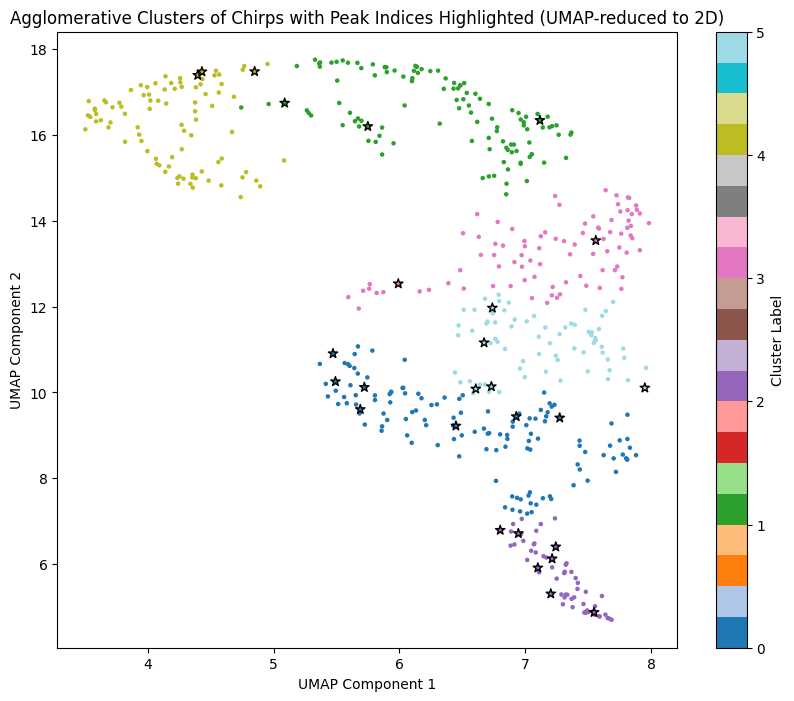

In [89]:
# plot only the significant peaks on the previous scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(filtered_chirp_data_2d[:, 0], filtered_chirp_data_2d[:, 1], c=filtered_chirp_labels, cmap="tab20", s=5,
                      vmin=min(chirp_labels), vmax=max(chirp_labels))
# overlay stars for peak_indices
significant_peak_chirp_clusters = chirp_labels[significant_peaks]
scatter_2 = plt.scatter(chirp_data_2d[significant_peaks, 0], chirp_data_2d[significant_peaks, 1], c=significant_peak_chirp_clusters, 
                        cmap="tab20", edgecolors="black", s=50, marker="*", vmin=min(chirp_labels), vmax=max(chirp_labels))
plt.title(f"{clustering} Clusters of Chirps with Peak Indices Highlighted ({'UMAP' if umap else 'PCA'}-reduced to 2D)")
plt.colorbar(scatter, label="Cluster Label")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
if not umap:
    plt.xlim(-8800, -8000);
    plt.ylim(-1400, -1000);

Run the significance check on all chirp sequences

In [90]:
# first create a dataframe like peak_df but for all chirps in df_tightness
# each unique file_id is a row
all_chirps_df = df_tightness.reset_index().groupby('file_id').agg({'index': lambda x: x.tolist()})
# rename index to surrounding_seq_idx
all_chirps_df = all_chirps_df.rename(columns={'index': 'surrounding_seq_idx'})
all_chirps_df["surrounding_seq_uncertainty"] = all_chirps_df["surrounding_seq_idx"].map(
    lambda indices: df_tightness.loc[indices, MEASURE].values
)
all_chirps_df["surround_seq_uncertainty_smoothed"] = all_chirps_df["surrounding_seq_idx"].map(
    lambda indices: gaussian_filter(df_tightness.loc[indices, MEASURE].values, sigma=SIGMA, order=0, mode='reflect')
)
all_chirps_df["seq_uncertainty_min"] = all_chirps_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.min())
all_chirps_df["seq_uncertainty_max"] = all_chirps_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.max())
all_chirps_df["seq_uncertainty_mean"] = all_chirps_df["surround_seq_uncertainty_smoothed"].map(lambda arr: arr.mean())
all_chirps_df["seq_uncertainty_range"] = all_chirps_df["seq_uncertainty_max"] - all_chirps_df["seq_uncertainty_min"]
all_chirps_df["normalized_surrounding_seq"] = all_chirps_df["surround_seq_uncertainty_smoothed"].map(
    lambda arr: (arr - arr.mean())
)
all_chirps_df.sort_values("seq_uncertainty_range")
all_chirps_df

,surrounding_seq_idx,surrounding_seq_uncertainty,surround_seq_uncertainty_smoothed,seq_uncertainty_min,seq_uncertainty_max,seq_uncertainty_mean,seq_uncertainty_range,normalized_surrounding_seq
file_id,,,,,,,,
1039,"[0, 1, 2, 3, 4, 5, 6]","[0.3956317138119913, 0.3695645535886351, 0.405...","[0.3884086327031424, 0.3866696816733842, 0.389...",0.376850,0.389528,0.385151,0.012678,"[0.0032581196704666304, 0.001519168640708446, ..."
1040,"[7, 8, 9, 10, 11, 12, 13, 14]","[0.3474040580544685, 0.33024642068323457, 0.30...","[0.33993764290297346, 0.33038821175055866, 0.3...",0.324995,0.417871,0.350512,0.092876,"[-0.010574551855528025, -0.020123983007942825,..."
1041,"[15, 16, 17, 18, 19, 20]","[0.404419075097464, 0.41197658715910135, 0.424...","[0.40775841639537014, 0.41152038242647027, 0.4...",0.348140,0.411520,0.389381,0.063380,"[0.018377272879391504, 0.022139238910491632, 0..."
1042,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]","[0.40613142425407495, 0.3832775671468322, 0.35...","[0.3963628740969228, 0.38187839922780664, 0.36...",0.313622,0.396363,0.361222,0.082740,"[0.03514074123638161, 0.020656266367265474, 1...."
1043,"[32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 4...","[0.42352249990263074, 0.44689182878313083, 0.3...","[0.428121433627882, 0.42065521477859824, 0.393...",0.295490,0.428121,0.334566,0.132631,"[0.09355583997480565, 0.08608962112552188, 0.0..."
1044,"[46, 47, 48, 49, 50, 51, 52]","[0.3671663387166035, 0.3618841735044521, 0.344...","[0.3639814354338765, 0.35604176377948127, 0.33...",0.296805,0.363981,0.327819,0.067177,"[0.036162585794876356, 0.028222914140481115, 0..."
1045,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]","[0.419557731009881, 0.3363894437343837, 0.2958...","[0.38708881915309445, 0.34827184841786757, 0.3...",0.293371,0.387089,0.328159,0.093717,"[0.058930021958669865, 0.02011305122344298, -0..."
1046,"[64, 65, 66, 67, 68, 69, 70, 71]","[0.3226019779456976, 0.3382479102636372, 0.290...","[0.3253114097664913, 0.3204705141477813, 0.310...",0.310701,0.402833,0.349323,0.092132,"[-0.02401196615257123, -0.028852861771281213, ..."
1047,"[72, 73]","[0.3294965654059966, 0.4096293457580207]","[0.3578944658151302, 0.3812314453488871]",0.357894,0.381231,0.369563,0.023337,"[-0.011668489766878454, 0.011668489766878454]"


In [91]:
all_chirps_significant_peaks = []
for i in range(len(all_chirps_df)):
    significant_peak_idxs = identify_significant_peaks(all_chirps_df, i, 'normalized_surrounding_seq', "seq_uncertainty_range",
                                                             similarity_threshold=0.05,
                                                            #  std_threshold=2.0,
                                                             percentile_threshold=95
                                                            )
    if len(significant_peak_idxs) > 0:
            all_chirps_significant_peaks.extend(significant_peak_idxs)
# remove duplicates
all_chirps_significant_peaks = list(set(all_chirps_significant_peaks))
len(all_chirps_significant_peaks)

Number of similar sequences found: 1 total sample size: 7
Normality test p-value for pooled values: nan
chirps that pass percentile threshold: 1
Number of similar sequences found: 3 total sample size: 27
Normality test p-value for pooled values: 0.18282005348058794
chirps that pass percentile threshold: 1
Number of similar sequences found: 3 total sample size: 21
Normality test p-value for pooled values: 0.4840273607868787
chirps that pass percentile threshold: 0
Number of similar sequences found: 3 total sample size: 33
Normality test p-value for pooled values: 0.054918420513573214
chirps that pass percentile threshold: 0
Number of similar sequences found: 6 total sample size: 88
Normality test p-value for pooled values: 0.0043324512500850605
chirps that pass percentile threshold: 2
Number of similar sequences found: 2 total sample size: 12
Normality test p-value for pooled values: 0.10221665343371114
chirps that pass percentile threshold: 1
Number of similar sequences found: 3 total 

/tmp/ipykernel_13239/3508771496.py:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  normaltest_result = normaltest(pooled_values)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypot

40

In this section, I investigate whether chirps within an idiom sequence are more similar with each other than with other chirps.

There are perhaps a few different ways to do this.
1. Find the volumn/density defined by an idiom sequence. Then pull a non-idiom sequence of the same length and find its volumn/density. Do this many times (using random samples) to produce two distributions, then run a statistical test to see if the idiom distribution mean is smaller.
2. Take a random sample of idioms. Do pairwise idiom-internal chirp comparison (something like cosine similarity) to generate a distribution of idiom-internal chirp similarity. Then randomly sample other chirps and do pairwise comparison between two chirps not in the same idiom to generate another distribution. Run a statistical test to see if the idiom-internal distribution mean is smaller.

In [92]:
# Function: get_random_sequence
# ---------------------------
# This function retrieves a random sequence of 'n' chirp indices from the unscaled_truth_df,
# ensuring that none of the indices in the selected sequence overlap with any indices
# present in the existing_sequences list.
# Parameters:
# - n: The desired length of the chirp index sequence to retrieve.
# - existing_sequences: A list of lists, where each inner list contains chirp indices
#   that should not be included in the new sequence.
# - unscaled_truth_df: A DataFrame containing chirp data
# Return: A list of 'n' chirp indices that do not overlap with existing_sequences.

def get_random_sequence(n, existing_sequences, unscaled_truth_df):
    existing_set = set()
    for seq in existing_sequences:
        existing_set.update(seq)

    file_ids = unscaled_truth_df['file_id'].unique()
    while True:
        file_id = np.random.choice(file_ids)
        file_chirps = unscaled_truth_df[unscaled_truth_df['file_id'] == file_id]
        if file_chirps.shape[0] < n:
            continue
        start_idx = np.random.randint(0, file_chirps.shape[0] - n + 1)
        seq_indices = file_chirps.index[start_idx:start_idx + n].tolist()
        if not any(idx in existing_set for idx in seq_indices):
            return seq_indices
        
# get_random_sequence(5, whole_idiom_sequences, unscaled_truth_list_0)

In [93]:
# Function: get_random_idiom_sequence
# ---------------------------
# This function retrieves a random idiom sequence of length n from the idiom_df
# Parameters:
# - n: The desired length of the idiom sequence to retrieve.
# - idiom_df: A DataFrame containing idiom sequences and their chirp indices.
# Return: A list of 'n' chirp indices that make up the idiom sequence

def get_random_idiom_sequence(n, idiom_df):
    idiom_sequences = idiom_df[idiom_df['length'] >= n]['chirp_indices'].index
    if not idiom_sequences.any():
        raise ValueError("No idiom sequences of sufficient length found.")
    selected_idiom = idiom_df.iloc[np.random.choice(idiom_sequences)]['chirp_indices']
    start_idx = np.random.randint(0, len(selected_idiom) - n + 1)
    return selected_idiom[start_idx:start_idx + n]

# get_random_idiom_sequence(5, whole_idiom_df)

In [94]:
# Function: get_attributes_from_indices
# --------------------------------------
# This function retrieves chirp attributes from the unscaled_truth_df
# based on a provided list of chirp indices.
# Parameters:
# - indices: A list of chirp indices for which to retrieve attributes.
# - unscaled_truth_df: A DataFrame containing chirp data.
# Return: A list of chirp attributes corresponding to the provided indices.

def get_attributes_from_indices(indices, unscaled_truth_df):
    return [unscaled_truth_df.iloc[i]["PrecedingIntrvl":"AmpK@start"].values for i in indices]

# get_attributes_from_indices(get_random_sequence(5, whole_idiom_sequences, unscaled_truth_list_0), unscaled_truth_list_0)

In [95]:
# Function: calculate_sequence_volume
# --------------------------------------
# This function calculates the spherical volume in hyperspace occupied by a sequence of chirp attributes.
# Parameters:
# - attributes: A list of chirp attributes, where each attribute is a numpy array.
# Return: The calculated volume as a float.

def calculate_sequence_volume(attributes):
    centroid = np.mean(attributes, axis=0)
    distances = np.linalg.norm(attributes - centroid, axis=1)
    radius = np.max(distances)
    dim = attributes[0].shape[0]
    volume = (np.pi ** (dim / 2)) / special.gamma((dim / 2) + 1) * (radius ** dim)
    return volume

calculate_sequence_volume(get_attributes_from_indices(get_random_sequence(5, whole_idiom_sequences, unscaled_truth_list_0), unscaled_truth_list_0))

1.7449652276335665e+115

In [96]:
whole_idiom_df = pd.DataFrame({"chirp_indices": whole_idiom_sequences})
whole_idiom_df["chirp_attributes"] = whole_idiom_df["chirp_indices"].map(
    lambda indices: get_attributes_from_indices(indices, unscaled_truth_list_0)
)
whole_idiom_df["length"] = whole_idiom_df["chirp_indices"].map(lambda indices: len(indices))
whole_idiom_df

,chirp_indices,chirp_attributes,length
0,"[75, 76, 77, 78, 79, 80, 81]","[[80.0, 83.8229920291284, 32.858530960762415, ...",7
1,"[291, 292, 293, 294, 295, 296]","[[60.0, 98.31374454940821, 51.022101577980884,...",6
2,"[315, 316, 317, 318, 319, 320]","[[98.0, 101.21717977367906, 56.32818539347896,...",6
3,"[328, 329, 330, 331, 332, 333, 334, 335, 336, ...","[[75.0, 92.97957182118711, 47.77898294292706, ...",10
4,"[349, 350, 351, 352, 353, 354, 355, 356, 357, ...","[[77.0, 100.44377845431616, 52.59880397643101,...",11
5,"[366, 367, 368, 369, 370, 371, 372]","[[93.0, 63.76997736716764, 21.859531847233903,...",7
6,"[382, 383, 384, 385, 386]","[[86.0, 89.95990004192065, 41.73724793250939, ...",5
7,"[437, 438, 439, 440, 441, 442, 443]","[[79.0, 80.12231100724854, 35.05486604844094, ...",7
8,"[462, 463, 464, 465, 466]","[[81.0, 75.30779614141126, 30.530438060774582,...",5
9,"[467, 468, 469, 470, 471, 472]","[[80.0, 99.90940329596334, 55.50141917136326, ...",6


In [97]:
# Approach 1: 
# get a distribution of idiom volumes by randomly sampling sequences of chirps
SAMPLE_SIZE = 1000
SEQ_LENGTH = 3
idiom_volumes = []
for _ in range(SAMPLE_SIZE):
    seq = get_random_idiom_sequence(SEQ_LENGTH, whole_idiom_df)
    attributes = get_attributes_from_indices(seq, unscaled_truth_list_0)
    volume = calculate_sequence_volume(attributes)
    idiom_volumes.append(volume)
idiom_volumes = np.array(idiom_volumes)

# get a distribution of non-idiom volumes by randomly sampling sequences of chirps that do not overlap with idioms
non_idiom_volumes = []
for _ in range(SAMPLE_SIZE):
    seq = get_random_sequence(SEQ_LENGTH, whole_idiom_sequences, unscaled_truth_list_0)
    attributes = get_attributes_from_indices(seq, unscaled_truth_list_0)
    volume = calculate_sequence_volume(attributes)
    non_idiom_volumes.append(volume)
non_idiom_volumes = np.array(non_idiom_volumes)

if SAMPLE_SIZE < 20:
    print("Idiom volumes:", idiom_volumes)
    print("Non-idiom volumes:", non_idiom_volumes)

# scale down the volumes by 1e100 to avoid overflow in t-test
idiom_volumes /= 1e100
non_idiom_volumes /= 1e100

# take the log of the volumes (NOT STATISTICALLY EQUIVALENT TO SCALING)
# idiom_volumes = np.log(idiom_volumes + 1e-12)
# non_idiom_volumes = np.log(non_idiom_volumes + 1e-12)

if SAMPLE_SIZE < 20:
    print("Scaled idiom volumes:", idiom_volumes)
    print("Scaled non-idiom volumes:", non_idiom_volumes)

# run a statistical t-test to compare the two distributions
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(idiom_volumes, non_idiom_volumes, equal_var=False, alternative='less')
print(f"Idiom volumes (scaled): mean = {np.mean(idiom_volumes):.4e}, std = {np.std(idiom_volumes):.4e}")
print(f"Non-idiom volumes (scaled): mean = {np.mean(non_idiom_volumes):.4e}, std = {np.std(non_idiom_volumes):.4e}")
print(f"T-test results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

Idiom volumes (scaled): mean = 1.0565e+21, std = 9.3496e+21
Non-idiom volumes (scaled): mean = 2.1165e+23, std = 3.5821e+24
T-test results: t-statistic = -1.8582, p-value = 0.0317


In [98]:
import scipy.spatial
# Approach 2:
# get a random sample of idiom sequences; within each sequence, calculate pairwise distances (euclidean) between chirps
SAMPLE_SIZE = 400
SEQ_LENGTH = 5
idiom_pairwise_distances = []
non_idiom_pairwise_distances = []
for _ in tqdm(range(SAMPLE_SIZE)):
    seq = get_random_idiom_sequence(SEQ_LENGTH, whole_idiom_df)
    attributes = get_attributes_from_indices(seq, unscaled_truth_list_0)
    # pick a random chirp in attributes and calculate distances to all other chirps
    ref_idx = np.random.randint(0, len(attributes))
    ref_chirp = attributes[ref_idx]
    for i, chirp in enumerate(attributes):
        if i == ref_idx:
            continue
        dist = scipy.spatial.distance.euclidean(ref_chirp, chirp)
        idiom_pairwise_distances.append(dist)

    # pick SEQ_LENGTH - 1 random chirps not in the idiom sequence and calculate distances to the same ref_chirp
    non_idiom_indices = []
    for i in range(SEQ_LENGTH - 1):
        seq = get_random_sequence(1, whole_idiom_sequences, unscaled_truth_list_0)
        non_idiom_indices.append(seq[0])

    non_idiom_attributes = get_attributes_from_indices(non_idiom_indices, unscaled_truth_list_0)
    for chirp in non_idiom_attributes:
        dist = scipy.spatial.distance.euclidean(ref_chirp, chirp)
        non_idiom_pairwise_distances.append(dist)

idiom_pairwise_distances = np.array(idiom_pairwise_distances)
non_idiom_pairwise_distances = np.array(non_idiom_pairwise_distances)

if SAMPLE_SIZE <= 10:
    print("Idiom pairwise distances:", idiom_pairwise_distances)
    print("Non-idiom pairwise distances:", non_idiom_pairwise_distances)

# run a statistical t-test to compare the two distributions
t_stat, p_value = ttest_ind(idiom_pairwise_distances, non_idiom_pairwise_distances, equal_var=False, alternative='less')
print(f"Idiom pairwise distances: mean = {np.mean(idiom_pairwise_distances):.4e}, std = {np.std(idiom_pairwise_distances):.4e}")
print(f"Non-idiom pairwise distances: mean = {np.mean(non_idiom_pairwise_distances):.4e}, std = {np.std(non_idiom_pairwise_distances):.4e}")
print(f"T-test results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

100%|██████████| 400/400 [00:01<00:00, 394.55it/s]

Idiom pairwise distances: mean = 9.2786e+03, std = 3.9343e+03
Non-idiom pairwise distances: mean = 9.6777e+03, std = 4.1840e+03
T-test results: t-statistic = -2.7790, p-value = 0.0027


In this section, I investigate potential patterns in the identified "low-confidence" predictions by looking at the SonoBat Cumulative SonoBatch file to see if there is a relationship between the confidence and the species

In [99]:
assert raw_audio_folder != None, "only proceed if raw_audio_folder is specified"

AssertionError: only proceed if raw_audio_folder is specified

In [ ]:
# get all .txt files with CumulativeSonoBatch in the name but not BatchSummary or NightlySummary
cumulative_sonobatch_files = [
    fn for fn in sorted(os.listdir(raw_audio_folder))
    if os.path.isfile(os.path.join(raw_audio_folder, fn)) and fn.endswith(".txt") and "CumulativeSonoBatch" in fn and "BatchSummary" not in fn and "NightlySummary" not in fn]
# read in the cumulative sono batch files into a single dataframe
cumulative_sonobatch_dfs = []
for fn in cumulative_sonobatch_files:
    df = pd.read_csv(os.path.join(raw_audio_folder, fn), sep=None, engine="python")
    cumulative_sonobatch_dfs.append(df)
cumulative_sonobatch_df = pd.concat(cumulative_sonobatch_dfs, ignore_index=True)
cumulative_sonobatch_df

In [ ]:
# convert all Nan in SppAccp and Prob columns to string "NaN"
cumulative_sonobatch_df['SppAccp'] = cumulative_sonobatch_df['SppAccp'].fillna("NaN")
cumulative_sonobatch_df['Prob'] = cumulative_sonobatch_df['Prob'].fillna("NaN")

# adjust SppAccp and Prob to be the first element if it's a string with slashes
for i, val in enumerate(cumulative_sonobatch_df['SppAccp']):
    if isinstance(val, str) and '/' in val:
        cumulative_sonobatch_df.at[i, 'SppAccp'] = val.split('/')[0]
for i, val in enumerate(cumulative_sonobatch_df['Prob']):
    if isinstance(val, str) and '/' in val:
        cumulative_sonobatch_df.at[i, 'Prob'] = val.split('/')[0]

In [ ]:
# using peak_filenames, find the corresponding rows in cumulative_sonobatch_df and extract relevant columns
peak_sonobatch_info = []
for (filename, file_id, chirp_idx, time_in_file) in peak_filenames:
    matching_rows = cumulative_sonobatch_df[cumulative_sonobatch_df['Filename'] == filename]
    if not matching_rows.empty:
        row = matching_rows.iloc[0]
        peak_sonobatch_info.append({
            "filename": filename,
            "file_id": file_id,
            "chirp_idx": chirp_idx,
            "time_in_file": time_in_file,
            "SppAccp": row.get("SppAccp", np.nan),
            "Prob": row.get("Prob", np.nan),
        })
peak_sonobatch_info_df = pd.DataFrame(peak_sonobatch_info)

# truncate prob to 2 decimal places
peak_sonobatch_info_df['Prob'] = peak_sonobatch_info_df['Prob'].astype(float).round(2)
peak_sonobatch_info_df

In [ ]:
peak_sonobatch_info_df['SppAccp'].value_counts().plot.bar()
plt.title("Species Distribution for Peak Chirps")
plt.xlabel("Species")
plt.ylabel("Count");

In [ ]:
# use filename_to_id_path to find the filenames in the test set
test_range = range(min_file_id, max_file_id)
test_filenames = filename_to_id_df[filename_to_id_df['file_id'].isin(test_range)]['Filename'].tolist()
# filter cumulative_sonobatch_df to only those filenames
test_sonobatch_df = cumulative_sonobatch_df[cumulative_sonobatch_df['Filename'].isin(test_filenames)]
test_sonobatch_df['SppAccp'].value_counts().plot.bar()
plt.title("Species Distribution in Test Set")
plt.xlabel("Species")
plt.ylabel("Count");